# Class 18: Finding Structure in High-Dimensional Sports Data

**CNET 5442 — Sports Analytics Through Data and Networks — Spring 2026**

---


We have event data from every match in the 2022 FIFA World Cup — passes, shots, carries, duels, tackles, for all 32 teams. That's a lot of numbers. Too many to look at directly.

So we need ways to compress and organize this data. Which teams play similarly? Are there distinct tactical styles, or is it a continuum? Can we find structure that nobody told us to look for?

We have two core tools:

1. **Embeddings** — compress each team from a high-dimensional feature vector into a 2D picture we can actually look at.
2. **Clustering** — assign each object to a group, without being told the groups in advance.

## Questions to keep in view

- When does a 2D picture faithfully represent high-dimensional structure — and when does it lie?
- What does "similar" even mean when your features have different units and scales?
- How many clusters are there? (Spoiler: no algorithm can answer this for you.)
- Can we discover playing styles from StatsBomb event data without labeling anything?

## Learning goals

By the end of this notebook you should be able to:

1. Explain the curse of dimensionality and why scaling matters.
2. Derive and implement **PCA** from scratch using eigendecomposition.
3. Use **classical MDS** to embed a distance matrix.
4. Run **t-SNE** and **UMAP** and explain what they preserve and what they don't.
5. Implement **k-means** from scratch (Lloyd's algorithm) and diagnose it.
6. Apply **hierarchical clustering**, **DBSCAN**, and **Gaussian mixture models**.
7. Evaluate clusterings with internal and external metrics.
8. Build a full pipeline — *featurize → scale → embed → cluster → interpret* — on real soccer data.

## Notation and conventions

| Symbol | Meaning |
|:---|:---|
| $n$ | Number of observations (teams, players, possessions) |
| $p$ | Number of features (dimensions) |
| $X \in \mathbb{R}^{n \times p}$ | Data matrix: $n$ rows, $p$ columns |
| $x_i \in \mathbb{R}^p$ | Row $i$ of $X$ (one observation) |
| $k$ | Target embedding dimension |
| $K$ | Number of clusters |
| $c_i \in \{1, \dots, K\}$ | Cluster assignment for observation $i$ |
| $\mu_k$ | Center (mean) of cluster $k$ |

---

## 0. Setup

In [1]:
# ── core stack ──
import json, math, warnings
from collections import Counter
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy.spatial.distance import pdist, squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs, make_moons, load_digits
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score,
    normalized_mutual_info_score, confusion_matrix,
)

SEED = 5442
RNG = np.random.default_rng(SEED)

plt.rc("axes", axisbelow=True)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "figure.dpi": 150})
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
try:
    import umap
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False
    print("umap-learn not available — UMAP sections will be skipped.")
    print("Install with: pip install umap-learn")

print("Ready.")

/Users/brennan/.conda/envs/cnet5442/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


### 0.1 Loading StatsBomb World Cup data

We'll pull event data from every match in the **2022 FIFA World Cup** directly from the StatsBomb open-data repository on GitHub. If the files are already cached locally, we skip the download.

In [3]:
# ── StatsBomb config ──
OPEN_DATA_BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
DATA_ROOT = Path("data") / "statsbomb_open_data"

RENAME_MAP = {
    "type.name": "event_type", "team.name": "team_name",
    "player.name": "player_name", "possession_team.name": "possession_team_name",
    "play_pattern.name": "play_pattern_name",
    "pass.recipient.name": "pass_recipient_name",
    "pass.end_location": "pass_end_location",
    "pass.height.name": "pass_height_name", "pass.type.name": "pass_type_name",
    "pass.outcome.name": "pass_outcome_name", "pass.length": "pass_length",
    "shot.outcome.name": "shot_outcome_name", "shot.statsbomb_xg": "shot_xg",
    "dribble.outcome.name": "dribble_outcome_name",
    "duel.type.name": "duel_type_name", "duel.outcome.name": "duel_outcome_name",
    "carry.end_location": "carry_end_location",
}

STRUCTURAL_EVENTS = {
    "Starting XI", "Half Start", "Half End", "Substitution",
    "Tactical Shift", "Injury Stoppage", "Player Off", "Player On",
    "Bad Behaviour", "Referee Ball-Drop",
}

In [4]:
def ensure_json(relative_path):
    """Download a StatsBomb JSON file if not already cached locally."""
    rel = Path(relative_path)
    local = DATA_ROOT / rel
    local.parent.mkdir(parents=True, exist_ok=True)
    if not local.exists():
        url = f"{OPEN_DATA_BASE}/{rel.as_posix()}"
        print(f"  downloading {rel} ...")
        urllib.request.urlretrieve(url, local)
    return local

def load_matches(competition_id, season_id):
    path = ensure_json(f"matches/{competition_id}/{season_id}.json")
    with open(path) as f:
        return json.load(f)

def extract_xy(loc):
    if isinstance(loc, (list, tuple)) and len(loc) >= 2:
        return float(loc[0]), float(loc[1])
    return np.nan, np.nan

In [5]:
def load_match_events(match_id):
    """Load, flatten, and lightly clean event data for one match."""
    path = ensure_json(f"events/{match_id}.json")
    with open(path) as f:
        raw = json.load(f)
    df = pd.json_normalize(raw, sep=".")
    df = df.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df.columns})
    df["match_id"] = match_id
    if "location" in df.columns:
        xy = df["location"].apply(lambda loc: pd.Series(extract_xy(loc)))
        df["x"], df["y"] = xy[0], xy[1]
    else:
        df["x"], df["y"] = np.nan, np.nan
    df["is_gameplay"] = ~df["event_type"].isin(STRUCTURAL_EVENTS)
    return df

In [6]:
# ── Download all 2022 World Cup matches ──
WC_COMP, WC_SEASON = 43, 106
matches_raw = load_matches(WC_COMP, WC_SEASON)
matches_df = pd.json_normalize(matches_raw, sep=".")

match_ids = matches_df["match_id"].tolist()
print(f"Found {len(match_ids)} matches in the 2022 World Cup.")

all_events = []
for mid in match_ids:
    all_events.append(load_match_events(mid))

events_df = pd.concat(all_events, ignore_index=True)
print(f"Total events loaded: {len(events_df):,}")
print(f"Unique teams: {events_df['team_name'].nunique()}")
print(f"Event types: {events_df['event_type'].nunique()}")

Found 64 matches in the 2022 World Cup.
Total events loaded: 234,652
Unique teams: 32
Event types: 33


In [7]:
events_df["event_type"].value_counts().head(15)

event_type
Pass              68515
Ball Receipt*     63715
Carry             53764
Pressure          16553
Ball Recovery      5821
Duel               4389
Clearance          2684
Block              2386
Dribble            1793
Goal Keeper        1790
Foul Committed     1775
Miscontrol         1755
Foul Won           1693
Shot               1494
Dispossessed       1431
Name: count, dtype: int64

### 0.2 Building team feature vectors

We need to turn this pile of events into a **feature matrix** — one row per team, many columns. What features capture playing style?

We'll compute per-90-minute rates for each team across all their World Cup matches. This normalizes for the fact that teams that go further play more games.

In [8]:
gameplay = events_df[events_df["is_gameplay"]].copy()
team_matches = events_df.groupby("team_name")["match_id"].nunique().rename("n_matches")
# 90 min per match is approximate (ignores extra time) but standard
team_minutes = team_matches * 90

def team_event_rate(event_type):
    counts = gameplay[gameplay["event_type"] == event_type].groupby("team_name").size()
    return (counts / team_minutes * 90).fillna(0)

def team_pass_completion():
    passes = gameplay[gameplay["event_type"] == "Pass"].copy()
    passes["complete"] = passes["pass_outcome_name"].isna()  # NaN = success in StatsBomb
    return passes.groupby("team_name")["complete"].mean()

def team_mean_pass_length():
    passes = gameplay[gameplay["event_type"] == "Pass"].copy()
    if "pass_length" in passes.columns:
        return passes.groupby("team_name")["pass_length"].mean()
    return pd.Series(dtype=float)

In [9]:
def team_mean_xg_per_shot():
    shots = gameplay[gameplay["event_type"] == "Shot"].copy()
    if "shot_xg" in shots.columns:
        return shots.groupby("team_name")["shot_xg"].mean()
    return pd.Series(dtype=float)

def team_mean_x_position():
    return gameplay.dropna(subset=["x"]).groupby("team_name")["x"].mean()

def team_carry_distance():
    carries = gameplay[gameplay["event_type"] == "Carry"].copy()
    if "carry_end_location" in carries.columns:
        def dist(row):
            end = row["carry_end_location"]
            if isinstance(end, (list, tuple)) and len(end) >= 2:
                return np.sqrt((end[0] - row["x"])**2 + (end[1] - row["y"])**2)
            return np.nan
        carries["dist"] = carries.apply(dist, axis=1)
        return carries.groupby("team_name")["dist"].mean()
    return pd.Series(dtype=float)

In [10]:
features = pd.DataFrame(index=team_matches.index)
features["passes_per90"] = team_event_rate("Pass")
features["shots_per90"] = team_event_rate("Shot")
features["carries_per90"] = team_event_rate("Carry")
features["dribbles_per90"] = team_event_rate("Dribble")
features["ball_recoveries_per90"] = team_event_rate("Ball Recovery")
features["interceptions_per90"] = team_event_rate("Interception")
features["clearances_per90"] = team_event_rate("Clearance")
features["fouls_per90"] = team_event_rate("Foul Committed")
features["duels_per90"] = team_event_rate("Duel")
features["pass_completion"] = team_pass_completion()
features["mean_pass_length"] = team_mean_pass_length()
features["mean_xg_per_shot"] = team_mean_xg_per_shot()
features["mean_x_position"] = team_mean_x_position()
features["mean_carry_dist"] = team_carry_distance()
features["n_matches"] = team_matches

features = features.fillna(0).sort_index()
print(f"Feature matrix: {features.shape[0]} teams x {features.shape[1]} features")
features.head(10)

Feature matrix: 32 teams x 15 features


,passes_per90,shots_per90,carries_per90,dribbles_per90,ball_recoveries_per90,interceptions_per90,clearances_per90,fouls_per90,duels_per90,pass_completion,mean_pass_length,mean_xg_per_shot,mean_x_position,mean_carry_dist,n_matches
team_name,,,,,,,,,,,,,,,
Argentina,659.285714,15.714286,537.571429,17.428571,46.428571,10.000000,20.142857,16.285714,35.428571,0.853521,19.613697,0.190804,59.339978,5.462550,7
Australia,426.750000,6.500000,290.250000,12.000000,43.000000,10.500000,23.750000,15.000000,38.000000,0.744581,22.856640,0.060699,53.360003,5.246484,4
Belgium,622.333333,11.666667,510.333333,12.333333,39.000000,7.666667,22.000000,10.333333,28.666667,0.855919,21.224172,0.105557,52.153629,5.018956,3
Brazil,639.200000,19.800000,532.800000,20.000000,53.400000,8.400000,13.800000,13.200000,34.600000,0.868586,18.909380,0.137743,61.550958,5.599315,5
Cameroon,420.333333,9.333333,309.666667,14.333333,47.666667,15.333333,22.333333,12.000000,31.000000,0.769231,23.824359,0.109527,55.297467,6.068108,3
Canada,523.666667,11.666667,435.333333,25.000000,53.000000,10.666667,17.000000,12.333333,21.666667,0.838956,21.356092,0.112246,59.844190,5.912879,3
Costa Rica,364.666667,3.666667,267.000000,11.333333,44.333333,12.000000,27.000000,10.333333,37.666667,0.758684,22.987959,0.112192,47.027404,4.906778,3
Croatia,644.428571,12.428571,524.857143,13.000000,47.428571,12.142857,22.428571,14.428571,35.428571,0.841499,19.753765,0.151376,57.597396,5.528384,7
Denmark,642.666667,11.666667,542.333333,15.666667,43.000000,11.000000,21.333333,11.333333,40.333333,0.836618,20.818615,0.091207,59.901440,4.518966,3


In [11]:
features.sort_values("n_matches", ascending=False)[["n_matches", "passes_per90", "shots_per90"]].head(10)

,n_matches,passes_per90,shots_per90
team_name,,,
Argentina,7,659.285714,15.714286
Croatia,7,644.428571,12.428571
Morocco,7,409.285714,9.428571
France,7,560.857143,15.142857
Netherlands,5,601.000000,9.600000
England,5,647.600000,12.600000
Brazil,5,639.200000,19.800000
Portugal,5,625.800000,13.200000
Switzerland,4,508.750000,9.250000


The finalists (Argentina, France) should have the most matches. Teams eliminated in the group stage have 3. We have a feature matrix with 32 teams and 15 features.

---

# Part I — Embedding: From High Dimensions to Pictures

We want to visualize our 15-dimensional team data, look for patterns, and see which teams are similar. But we can't plot in 15D. We need to project down to 2 or 3 dimensions — and we need to do it in a way that preserves as much of the structure as possible.

![](images/silly_high_dim.png)

## 1.1 High dimensions are weird!

Before we talk about algorithms, let's build some geometric intuition about what goes wrong in high dimensions.

Generate $n$ random points in $\mathbb{R}^p$. Compute all pairwise Euclidean distances. Now increase $p$.

What happens to the distances?

In [12]:
dims = [2, 5, 10, 20, 50, 100, 200, 500]
n_pts = 300

rows = []
for p in dims:
    X_rand = RNG.normal(size=(n_pts, p))
    d = pdist(X_rand, metric="euclidean")
    rows.append({"p": p, "min_over_max": float(np.min(d) / np.max(d)),
                 "cv": float(np.std(d) / np.mean(d))})

df_conc = pd.DataFrame(rows)
df_conc

,p,min_over_max,cv
0,2,0.000623,0.522906
1,5,0.023582,0.314319
2,10,0.093912,0.218507
3,20,0.242913,0.163532
4,50,0.444018,0.097857
5,100,0.557697,0.069759
6,200,0.662152,0.047384
7,500,0.757942,0.032302


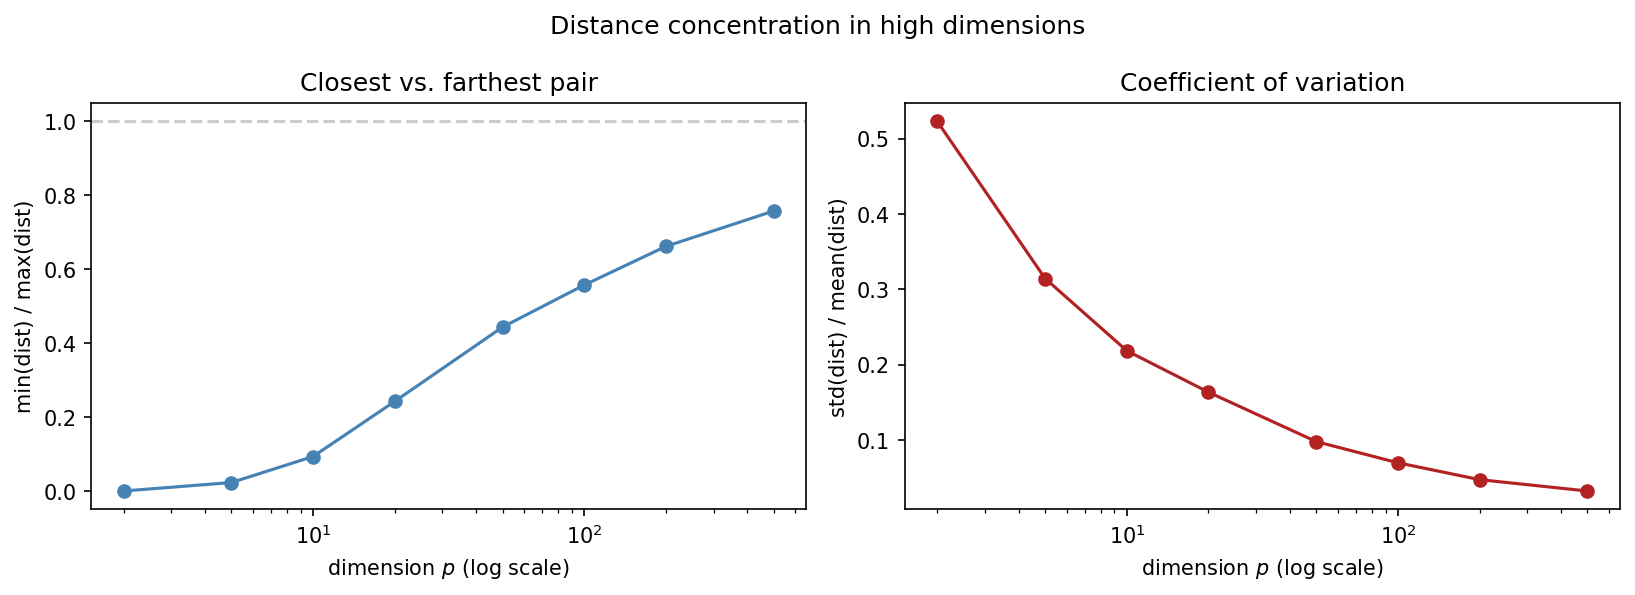

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(df_conc["p"], df_conc["min_over_max"], "o-", color="steelblue")
axes[0].set_xscale("log")
axes[0].set_xlabel("dimension $p$ (log scale)")
axes[0].set_ylabel("min(dist) / max(dist)")
axes[0].set_title("Closest vs. farthest pair")
axes[0].axhline(1, ls="--", color="gray", alpha=0.4)

axes[1].plot(df_conc["p"], df_conc["cv"], "o-", color="firebrick")
axes[1].set_xscale("log")
axes[1].set_xlabel("dimension $p$ (log scale)")
axes[1].set_ylabel("std(dist) / mean(dist)")
axes[1].set_title("Coefficient of variation")

fig.suptitle("Distance concentration in high dimensions", fontsize=12)
plt.tight_layout()
plt.show()

As $p$ grows, the closest and farthest pairs become nearly the same distance apart. The coefficient of variation shrinks toward zero.

In practice: if you're doing nearest-neighbor queries in 500 dimensions, the "nearest" neighbor isn't much closer than the farthest point.

So why bother reducing dimensions? If all pairwise distances are nearly equal, algorithms that rely on distance — nearest neighbors, clustering, classification — lose their ability to discriminate. We need to work in a space where distance still carries information.

The formal result (Beyer et al., 1999):

$$
\frac{\max_i d(x_i, q) - \min_i d(x_i, q)}{\min_i d(x_i, q)} \to 0 \quad \text{as } p \to \infty.
$$

The contrast between nearest and farthest neighbors vanishes.

## 1.2 Preprocessing: scaling and distance

Our team features have wildly different scales: `passes_per90` ~ 400, `mean_xg_per_shot` ~ 0.1, `mean_x_position` ~ 50. If we compute Euclidean distance on the raw features, `passes_per90` dominates — a 10-unit difference in passes swamps a 0.05 difference in xG, even though both might be equally meaningful for characterizing playing style.

The standard fix: **standardize** each feature to zero mean and unit variance.

$$
z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}
$$

- $\bar{x}_j$: mean of feature $j$.
- $s_j$: standard deviation of feature $j$.

In [14]:
x = np.array([10.0, 12.0, 14.0, 16.0])
mu = x.mean(); sigma = x.std(ddof=0)
z = (x - mu) / sigma

print("Raw:         ", x)
print(f"mean = {mu}, std = {sigma}")
print("Standardized:", np.round(z, 3))
print(f"mean = {z.mean():.6f}, std = {z.std():.6f}")

Raw:          [10. 12. 14. 16.]
mean = 13.0, std = 2.23606797749979
Standardized: [-1.342 -0.447  0.447  1.342]
mean = 0.000000, std = 1.000000


In [15]:
a = np.array([0.0, 0.0]); b = np.array([1.0, 1.0])
print(f"Raw distance: {np.linalg.norm(a - b):.3f}")

scales = np.array([1.0, 100.0])
print(f"After scaling: {np.linalg.norm(a/scales - b/scales):.3f}")
print("Feature 2 now contributes almost nothing to the distance.")

Raw distance: 1.414
After scaling: 1.000
Feature 2 now contributes almost nothing to the distance.


### Distance and similarity are modeling choices

Euclidean distance treats every feature equally (after scaling). But sometimes direction matters more than magnitude.

**Cosine similarity** measures the angle between two vectors:

$$
\cos(x, y) = \frac{x \cdot y}{\|x\| \, \|y\|}.
$$

When would you use cosine? When *profile shape* matters more than *magnitude*. Two teams with the same relative proportions of passes, shots, and carries but different total possession: cosine says similar, Euclidean says far apart.

In [16]:
x = np.array([1.0, 1.0, 0.0])
y = np.array([2.0, 2.0, 0.0])   # same direction, larger magnitude
z = np.array([1.0, -1.0, 0.0])  # different direction

def cosine_sim(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom else 0.0

print(f"cos(x, y) = {cosine_sim(x, y):.3f}  (same direction, different magnitude)")
print(f"cos(x, z) = {cosine_sim(x, z):.3f}  (different direction)")
print(f"euclid(x, y) = {np.linalg.norm(x - y):.3f}")
print(f"euclid(x, z) = {np.linalg.norm(x - z):.3f}")

cos(x, y) = 1.000  (same direction, different magnitude)
cos(x, z) = 0.000  (different direction)
euclid(x, y) = 1.414
euclid(x, z) = 2.000


Euclidean says $y$ is closer to $x$. Cosine says $y$ is *identical* to $x$. Neither is "right" — it depends on whether magnitude matters for your question.

## 1.3 PCA: projecting onto the best subspace

We have $n$ observations in $\mathbb{R}^p$ — each team is a point in 14-dimensional feature space. We want to project down to $k$ dimensions (usually 2 or 3) so we can plot it and see what's going on.

But which 2 dimensions? If we just pick two of the 14 features at random, we might pick two that barely vary, and miss all the action. We want the projection that keeps as much of the interesting variation as possible.

### What does "variance" mean here, and why maximize it?

Imagine projecting all 32 teams onto a single direction — a line through 14-dimensional space. Some directions will spread the teams out (teams look different from each other), and other directions will squash them together (teams look the same). We want the direction that spreads them out the most, because that's where the data is telling us something.

"Spread" is measured by **variance**: the average squared deviation from the mean. High variance = teams differ a lot along this direction. Low variance = teams are similar along this direction.

So the first principal component is: *find the single direction in feature space along which the projected data has the highest variance.*

### Som light math behind principle component analysis

First, **center** the data. Subtract the mean of each feature so that the cloud of points is centered at the origin. This lets us talk about directions through the origin without worrying about where the data happens to sit.

$$
X_c = X - \mathbf{1}\mu^T
$$

where $\mu \in \mathbb{R}^p$ is the vector of feature means.

Next, the **sample covariance matrix**:

$$
S = \frac{1}{n-1} X_c^T X_c \in \mathbb{R}^{p \times p}.
$$

What is $S$? Entry $S_{jk}$ measures how much features $j$ and $k$ vary together. The diagonal $S_{jj}$ is the variance of feature $j$. Off-diagonal entries are covariances — if $S_{jk}$ is large and positive, features $j$ and $k$ tend to go up together.

Now, the variance of the data projected onto a unit vector $w$ is:

$$
\mathrm{Var}(X_c w) = w^T S w.
$$

Why? The projection of each centered observation $x_i$ onto $w$ is the scalar $x_i \cdot w$. The variance of those scalars is $\frac{1}{n-1}\sum_i (x_i \cdot w)^2 = w^T S w$.

So the first PC solves:

$$
w_1 = \underset{\|w\|_2 = 1}{\arg\max}\; w^T S w.
$$

The constraint $\|w\| = 1$ prevents us from making the variance infinite by scaling $w$ up.

### Why eigenvectors?

How do we solve $\max_{\|w\|=1} w^TSw$? Use a Lagrange multiplier. Set the gradient to zero:

$$
Sw = \lambda w
$$

This is the eigenvector equation. The direction $w$ that maximizes the projected variance is an eigenvector of $S$, and the variance along that direction equals the eigenvalue $\lambda$.

Since $S$ is symmetric and positive semidefinite, all eigenvalues are $\ge 0$, and the eigenvectors are orthogonal. The eigenvector with the *largest* eigenvalue is PC1 (most variance). The next-largest is PC2 (most remaining variance, perpendicular to PC1). And so on.

Let's see this on a tiny 2D example.

In [17]:
n_pca = 200
theta = 30 * np.pi / 180
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

Z_latent = np.column_stack([RNG.normal(0, 3.0, n_pca), RNG.normal(0, 0.5, n_pca)])
X_pca2d = Z_latent @ R.T
Xc = X_pca2d - X_pca2d.mean(axis=0)

S = (Xc.T @ Xc) / (n_pca - 1)
evals, evecs = np.linalg.eigh(S)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
w1, w2 = evecs[:, 0], evecs[:, 1]

print(f"Eigenvalues: {evals[0]:.2f}, {evals[1]:.2f}")
print(f"Variance ratio: {evals[0]/evals.sum():.1%} in PC1, {evals[1]/evals.sum():.1%} in PC2")

Eigenvalues: 9.41, 0.26
Variance ratio: 97.3% in PC1, 2.7% in PC2


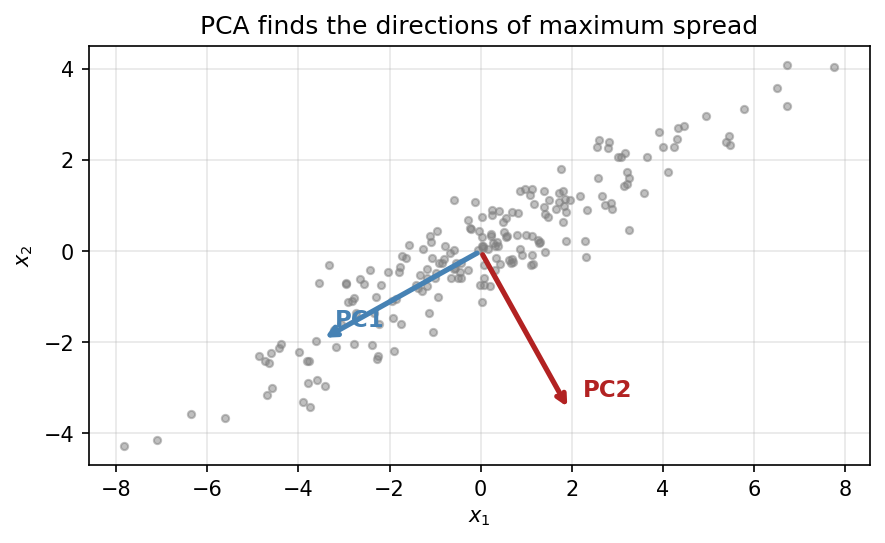

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Xc[:, 0], Xc[:, 1], s=12, alpha=0.5, color="gray")
sc = 4
ax.annotate("", xy=sc*w1, xytext=(0,0), arrowprops=dict(arrowstyle="->", color="steelblue", lw=2.5))
ax.annotate("", xy=sc*w2, xytext=(0,0), arrowprops=dict(arrowstyle="->", color="firebrick", lw=2.5))
ax.text(*(sc*w1+0.3), "PC1", color="steelblue", fontsize=11, fontweight="bold")
ax.text(*(sc*w2+0.3), "PC2", color="firebrick", fontsize=11, fontweight="bold")
ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("PCA finds the directions of maximum spread")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

PC1 (blue) points along the stretched-out direction. PC2 (red) is perpendicular. Projecting onto PC1 alone keeps most of the variance. Good trade.

What can go wrong with PCA? Two things to watch for. First, PCA is linear — if the real structure is curved (think: a Swiss roll), PCA will flatten it and mash distinct regions together. Second, outliers can hijack entire components. A single extreme point can pull PC1 toward itself, making the dominant direction about one weird observation rather than the main trend in the data.

### PCA from scratch

In practice, we don't compute $S$ and then eigendecompose it. Instead we use the **SVD** (singular value decomposition) of the centered data directly.

Why? Two reasons. First, forming $S = X_c^TX_c$ can amplify numerical errors — you're squaring things, and small floating-point errors get squared too. The SVD avoids this. Second, the SVD gives us the same answer: if $X_c = U\Sigma V^T$, then

$$
S = \frac{1}{n-1}X_c^TX_c = V\frac{\Sigma^2}{n-1}V^T.
$$

So the columns of $V$ are the eigenvectors of $S$ (the principal directions), and the eigenvalues are $\sigma_j^2/(n-1)$ (the variances along each direction).

In [19]:
def pca_from_scratch(X, n_components):
    """PCA via SVD, from scratch."""
    X = np.asarray(X, dtype=float)
    n, p = X.shape; k = n_components
    mean_ = X.mean(axis=0)
    Xc = X - mean_
    U, sigma, Vt = np.linalg.svd(Xc, full_matrices=False)
    components_ = Vt[:k]
    explained_var = (sigma[:k]**2) / (n - 1)
    total_var = (sigma**2).sum() / (n - 1)
    return {"mean_": mean_, "components_": components_,
            "explained_variance_": explained_var,
            "explained_variance_ratio_": explained_var / total_var}, Xc @ components_.T

In [20]:
# Sanity check against sklearn
X_test, _ = make_blobs(n_samples=300, n_features=5, centers=3, random_state=0)
X_test_std = StandardScaler().fit_transform(X_test)

model_scratch, Z_scratch = pca_from_scratch(X_test_std, 3)
pca_sk = PCA(n_components=3, svd_solver="full", random_state=0)
Z_sk = pca_sk.fit_transform(X_test_std)

for j in range(3):
    corr = abs(np.corrcoef(Z_scratch[:, j], Z_sk[:, j])[0, 1])
    print(f"PC{j+1} correlation: {corr:.6f}")
print(f"Variance ratios match: {np.allclose(model_scratch['explained_variance_ratio_'], pca_sk.explained_variance_ratio_)}")

PC1 correlation: 1.000000
PC2 correlation: 1.000000
PC3 correlation: 1.000000
Variance ratios match: True


### PCA diagnostics: explained variance

How many components to keep? The **scree plot** shows explained variance per component. Look for an elbow.

In [21]:
features

,passes_per90,shots_per90,carries_per90,dribbles_per90,ball_recoveries_per90,interceptions_per90,clearances_per90,fouls_per90,duels_per90,pass_completion,mean_pass_length,mean_xg_per_shot,mean_x_position,mean_carry_dist,n_matches
team_name,,,,,,,,,,,,,,,
Argentina,659.285714,15.714286,537.571429,17.428571,46.428571,10.000000,20.142857,16.285714,35.428571,0.853521,19.613697,0.190804,59.339978,5.462550,7
Australia,426.750000,6.500000,290.250000,12.000000,43.000000,10.500000,23.750000,15.000000,38.000000,0.744581,22.856640,0.060699,53.360003,5.246484,4
Belgium,622.333333,11.666667,510.333333,12.333333,39.000000,7.666667,22.000000,10.333333,28.666667,0.855919,21.224172,0.105557,52.153629,5.018956,3
Brazil,639.200000,19.800000,532.800000,20.000000,53.400000,8.400000,13.800000,13.200000,34.600000,0.868586,18.909380,0.137743,61.550958,5.599315,5
Cameroon,420.333333,9.333333,309.666667,14.333333,47.666667,15.333333,22.333333,12.000000,31.000000,0.769231,23.824359,0.109527,55.297467,6.068108,3
Canada,523.666667,11.666667,435.333333,25.000000,53.000000,10.666667,17.000000,12.333333,21.666667,0.838956,21.356092,0.112246,59.844190,5.912879,3
Costa Rica,364.666667,3.666667,267.000000,11.333333,44.333333,12.000000,27.000000,10.333333,37.666667,0.758684,22.987959,0.112192,47.027404,4.906778,3
Croatia,644.428571,12.428571,524.857143,13.000000,47.428571,12.142857,22.428571,14.428571,35.428571,0.841499,19.753765,0.151376,57.597396,5.528384,7
Denmark,642.666667,11.666667,542.333333,15.666667,43.000000,11.000000,21.333333,11.333333,40.333333,0.836618,20.818615,0.091207,59.901440,4.518966,3


In [22]:
feature_cols = [c for c in features.columns if c != "n_matches"]
X_teams = features[feature_cols].values
team_names = features.index.tolist()


scaler = StandardScaler()
X_teams_std = scaler.fit_transform(X_teams)
pca_full = PCA(svd_solver="full", random_state=0)


Z_full = pca_full.fit_transform(X_teams_std)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

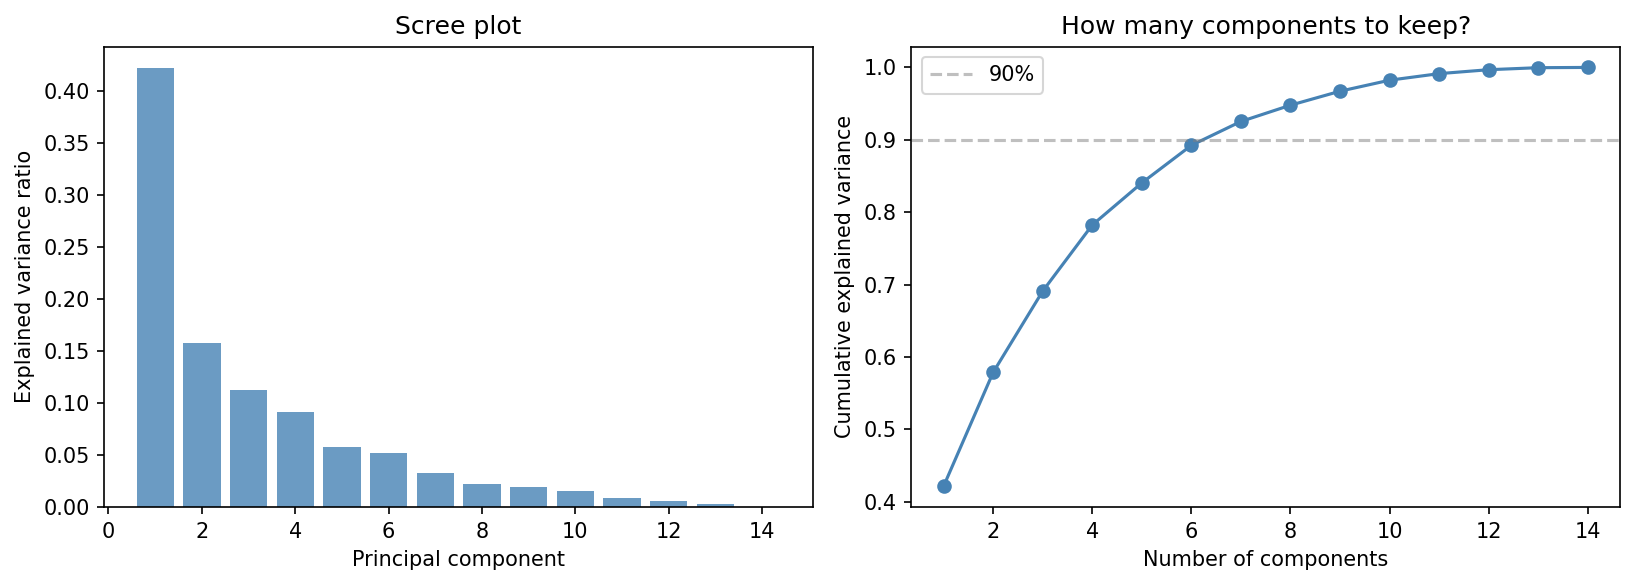

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal component"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(cumvar)+1), cumvar, "o-", color="steelblue")
axes[1].axhline(0.90, ls="--", color="gray", alpha=0.5, label="90%")
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("How many components to keep?"); axes[1].legend()
plt.tight_layout(); plt.show()

In [24]:
for i, cv in enumerate(cumvar[:7]):
    print(f"  {i+1} components: {cv:.1%}")

  1 components: 42.1%
  2 components: 57.9%
  3 components: 69.1%
  4 components: 78.2%
  5 components: 84.0%
  6 components: 89.2%
  7 components: 92.5%


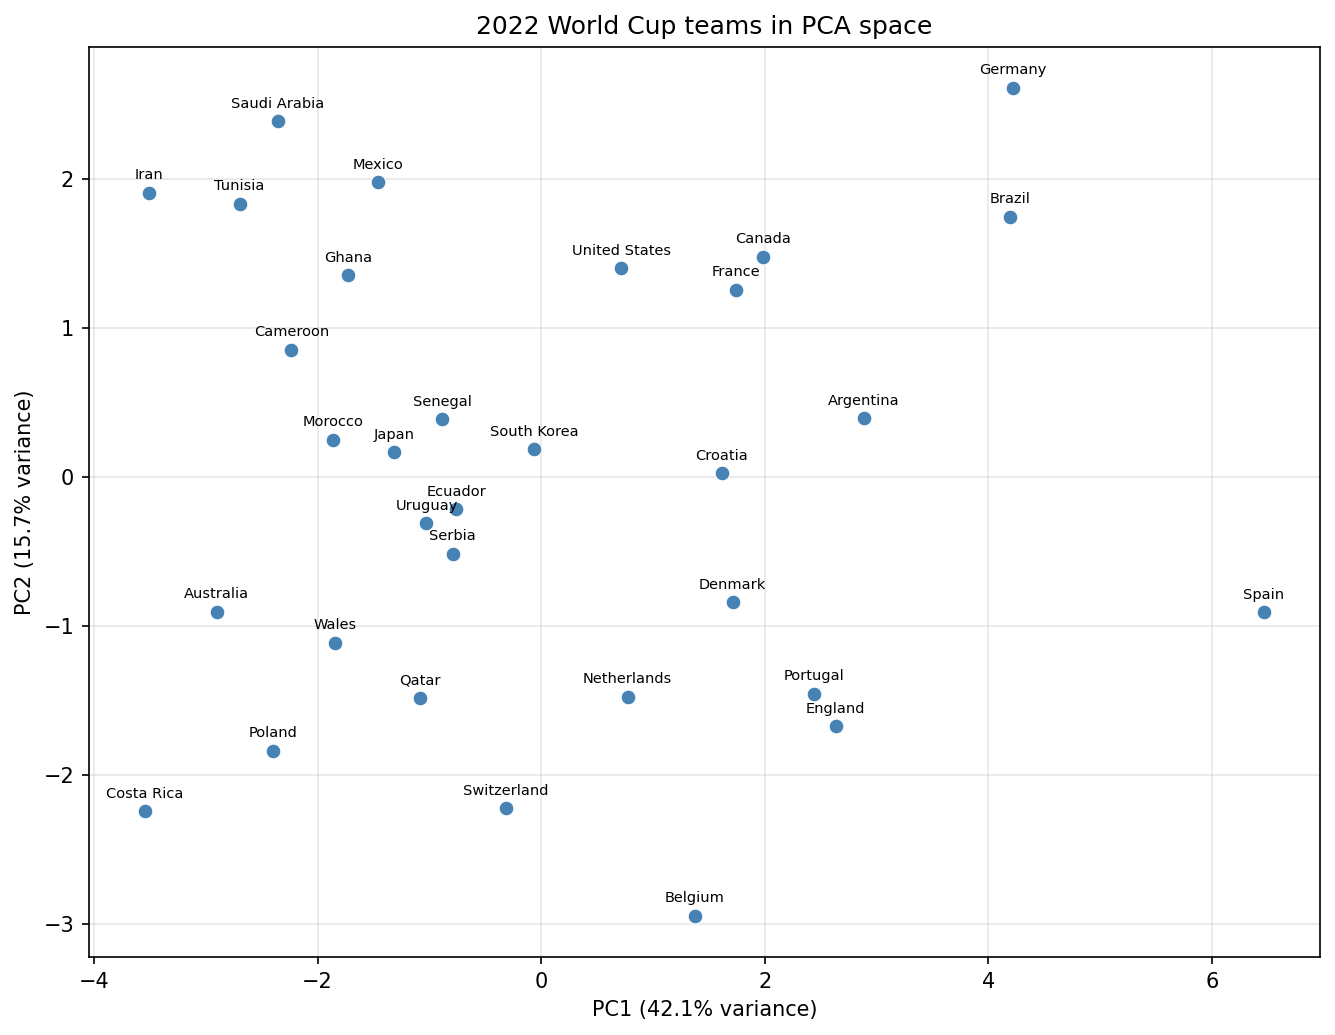

In [25]:
Z2 = Z_full[:, :2]
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(Z2[:, 0], Z2[:, 1], s=50, color="steelblue", edgecolors="white", linewidth=0.5)
for i, name in enumerate(team_names):
    ax.annotate(name, (Z2[i,0], Z2[i,1]), fontsize=7, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("2022 World Cup teams in PCA space")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Teams spread out along PC1. 

How do we figure out awht PC1 means? We need the loadings.

### Interpreting PCA: what do the axes mean?

The **loadings** tell us which original features contribute to each PC. If PC1 loads heavily on `passes_per90` and `pass_completion`, it roughly measures "possession dominance."

In [26]:
loadings = pd.DataFrame(pca_full.components_[:3].T, index=feature_cols, columns=["PC1","PC2","PC3"])
loadings.head()

,PC1,PC2,PC3
passes_per90,0.384534,-0.091557,0.038374
shots_per90,0.296277,0.338228,0.012902
carries_per90,0.387023,-0.080143,0.020288
dribbles_per90,0.227115,0.334584,-0.072178
ball_recoveries_per90,0.013753,0.553436,-0.198263


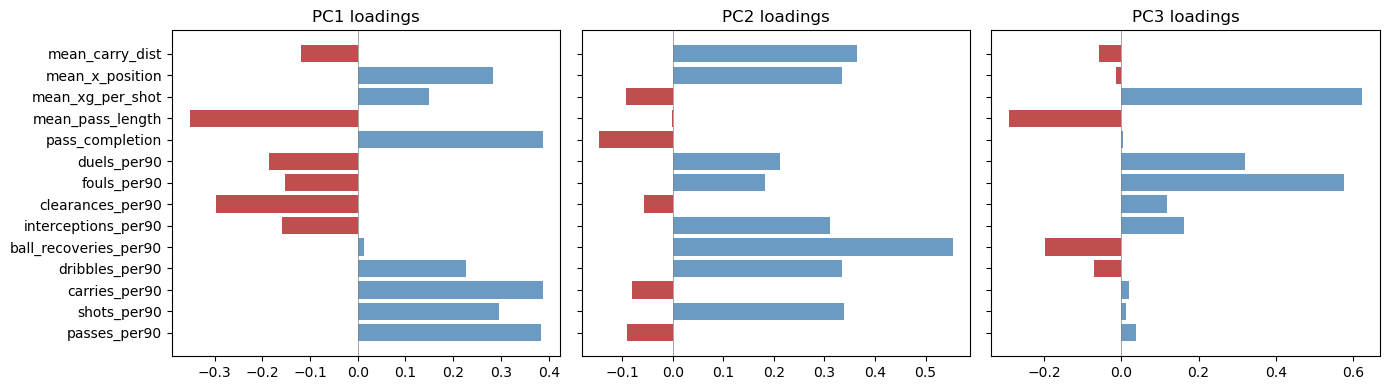

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, dpi=100)

for j, pc in enumerate(["PC1","PC2","PC3"]):
    colors = ["steelblue" if v >= 0 else "firebrick" for v in loadings[pc]]
    axes[j].barh(feature_cols, loadings[pc], color=colors, alpha=0.8)
    axes[j].set_title(f"{pc} loadings"); axes[j].axvline(0, color="gray", lw=0.5)

    
plt.tight_layout(); plt.show()

### Your turn!

1. What does PC1 seem to measure? PC2? Give each axis a plain-English name.
2. Pick two teams that are far apart in the PCA plot. What features drive that separation?
3. Why do we standardize *before* PCA? Try PCA on raw features and compare.

## 1.4 Classical MDS: embedding from distances

PCA starts with a feature matrix — each observation is a vector of measurements. But sometimes you don't have features at all. Maybe you have expert judgments of pairwise similarity, or network shortest-path distances, or some domain-specific distance metric. All you have is an $n \times n$ matrix $D$ of distances.

**Classical MDS** takes that distance matrix and finds coordinates $Y \in \mathbb{R}^{n \times k}$ such that the Euclidean distances between the coordinates approximate $D$ as well as possible.

### How does MDS recover coordinates from distances?

The trick is to convert distances into dot products. If you know all pairwise distances between points, you can (under the right conditions) figure out where the points must be.

Define the centering matrix $J = I - \frac{1}{n}\mathbf{11}^T$. Multiplying by $J$ on both sides centers the data (subtracts the mean). Then:

$$
B = -\frac{1}{2} J \, D^{(2)} \, J
$$

where $D^{(2)}$ is the matrix of *squared* distances. Under ideal conditions (when the distances are truly Euclidean), $B$ is a Gram matrix: $B = YY^T$, where $Y$ are the coordinates we want.

Why does squaring and centering convert distances to dot products? Because $\|x_i - x_j\|^2 = \|x_i\|^2 + \|x_j\|^2 - 2x_i \cdot x_j$. The centering removes the norm terms, leaving the dot products.

We eigendecompose $B$, take the top $k$ eigenvectors, and scale by the square roots of the eigenvalues to get coordinates.

In [28]:
def classical_mds(D, k):
    D = np.asarray(D, dtype=float); n = D.shape[0]
    J = np.eye(n) - np.ones((n,n))/n
    B = -0.5 * J @ (D**2) @ J
    evals, evecs = np.linalg.eigh(B)
    order = np.argsort(evals)[::-1]
    evals_k = np.maximum(evals[order[:k]], 0.0)
    return evecs[:, order[:k]] * np.sqrt(evals_k)

In [29]:
# Verify: embed a known point cloud, recover it
X_true = RNG.normal(size=(30, 2))
Y_mds = classical_mds(squareform(pdist(X_true)), k=2)

# Align via Procrustes
Xc_mds = X_true - X_true.mean(0); Yc = Y_mds - Y_mds.mean(0)
U, _, Vt = np.linalg.svd(Yc.T @ Xc_mds)
Y_aligned = Yc @ (U @ Vt)
print(f"RMS error: {np.sqrt(np.mean((Xc_mds - Y_aligned)**2)):.2e} (should be ~0)")

RMS error: 6.05e-16 (should be ~0)


**Connection to PCA:** MDS on the Euclidean distance matrix gives *exactly the same embedding* as PCA. Same algorithm, two entry points.

## 1.5 Nonlinear embeddings: t-SNE and UMAP

PCA and MDS are **linear**. But real data often lives on curved surfaces, or has cluster structure that a flat projection mashes together.

t-SNE and UMAP share a core strategy: build a graph of **local neighborhoods** in high-D, then find a low-D layout that preserves those neighborhoods.

### t-SNE: the intuition

The idea behind t-SNE is simple, even if the math looks involved.

In high dimensions, define a notion of "neighborhood" for each point: how likely is point $j$ to be point $i$'s neighbor? Points that are close get high probability; points that are far get low probability. This gives us a probability distribution over neighbors for each point.

Now do the same thing in 2D: place the points somewhere, and define neighborhood probabilities based on how close they are in the 2D layout.

The goal: adjust the 2D positions until the 2D neighborhood probabilities match the high-D ones as closely as possible. If point $j$ was a close neighbor of $i$ in 64 dimensions, it should be a close neighbor in 2D too.

The bandwidth $\sigma_i$ in the high-D probabilities is set by the **perplexity** parameter — roughly, how many effective neighbors each point has.

### The key trick: heavy tails in 2D

What makes t-SNE work well is using a **Student-t distribution** in the 2D space instead of a Gaussian.

Why? In high dimensions, there's a lot of "room" — points can be moderately far from each other and still all fit. In 2D, there's much less room. If you try to preserve all the moderate distances faithfully, the points get crushed together.

The Student-t distribution has heavier tails than a Gaussian. In the 2D layout, points that are moderately far apart exert less attractive force — they're allowed to drift further away. The effect: clusters spread out and separate visually.

The cost function is the KL divergence between the high-D and 2D probability distributions, minimized by gradient descent on the 2D positions.

Let's make perplexity concrete. The perplexity of a probability distribution $P$ is $2^{H(P)}$ where $H$ is the Shannon entropy in bits. A uniform distribution over 4 items has perplexity 4. A peaked distribution has low perplexity.

In [30]:
def perplexity(prob):
    """Perplexity = 2^H for a probability vector."""
    prob = np.asarray(prob, dtype=float)
    prob = prob[prob > 0] / prob.sum()
    H = -np.sum(prob * np.log2(prob))
    return float(2 ** H)

p_uniform = np.array([0.25, 0.25, 0.25, 0.25])
p_peaked = np.array([0.85, 0.05, 0.05, 0.05])

print(f"Uniform over 4: perplexity = {perplexity(p_uniform):.1f}")
print(f"Peaked [.85,.05,.05,.05]: perplexity = {perplexity(p_peaked):.2f}")
print(f"\nSo perplexity ~ effective number of neighbors.")

Uniform over 4: perplexity = 4.0
Peaked [.85,.05,.05,.05]: perplexity = 1.80

So perplexity ~ effective number of neighbors.


### Digits dataset: where t-SNE shines

8x8 grayscale images of digits 0–9. Each image is a point in $\mathbb{R}^{64}$.

In [31]:
digits = load_digits()
X_digits = digits.data.astype(float)
y_digits = digits.target
images_digits = digits.images
X_digits_std = StandardScaler().fit_transform(X_digits)
print(f"Digits: {X_digits.shape[0]} samples, {X_digits.shape[1]} features")

Digits: 1797 samples, 64 features


In [32]:
pca_digits = PCA(n_components=2, random_state=0)
Z_pca_digits = pca_digits.fit_transform(X_digits_std)

pca_30 = PCA(n_components=30, random_state=0)
X_pca30 = pca_30.fit_transform(X_digits_std)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")
Z_tsne_digits = tsne.fit_transform(X_pca30)

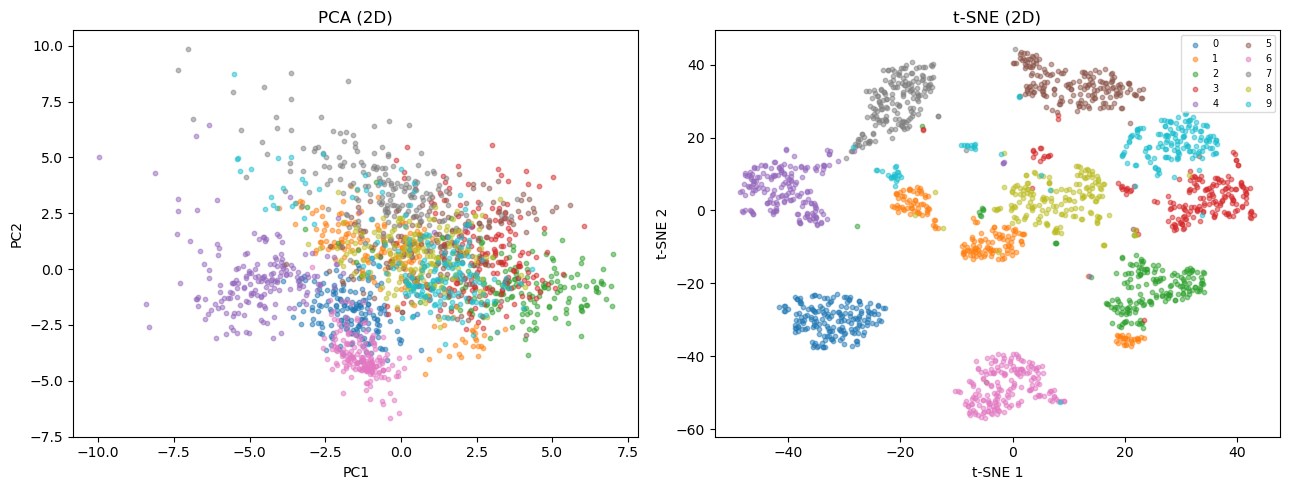

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)

for digit in range(10):
    mask = y_digits == digit
    axes[0].scatter(Z_pca_digits[mask,0], Z_pca_digits[mask,1], s=10, alpha=0.5, label=str(digit))
    axes[1].scatter(Z_tsne_digits[mask,0], Z_tsne_digits[mask,1], s=10, alpha=0.5, label=str(digit))
axes[0].set_title("PCA (2D)"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_title("t-SNE (2D)"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[1].legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.7)

plt.tight_layout()
plt.show()

In PCA, the digit classes overlap heavily — too much structure is lost in the linear projection. t-SNE pulls the classes apart into well-separated groups.

But don't over-read the picture: inter-cluster distances are meaningless, cluster sizes are artifacts, and different seeds give different layouts. t-SNE is a visualization tool, not a faithful map.

In [34]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
Z_umap_digits = reducer.fit_transform(X_pca30)

/Users/brennan/.conda/envs/cnet5442/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


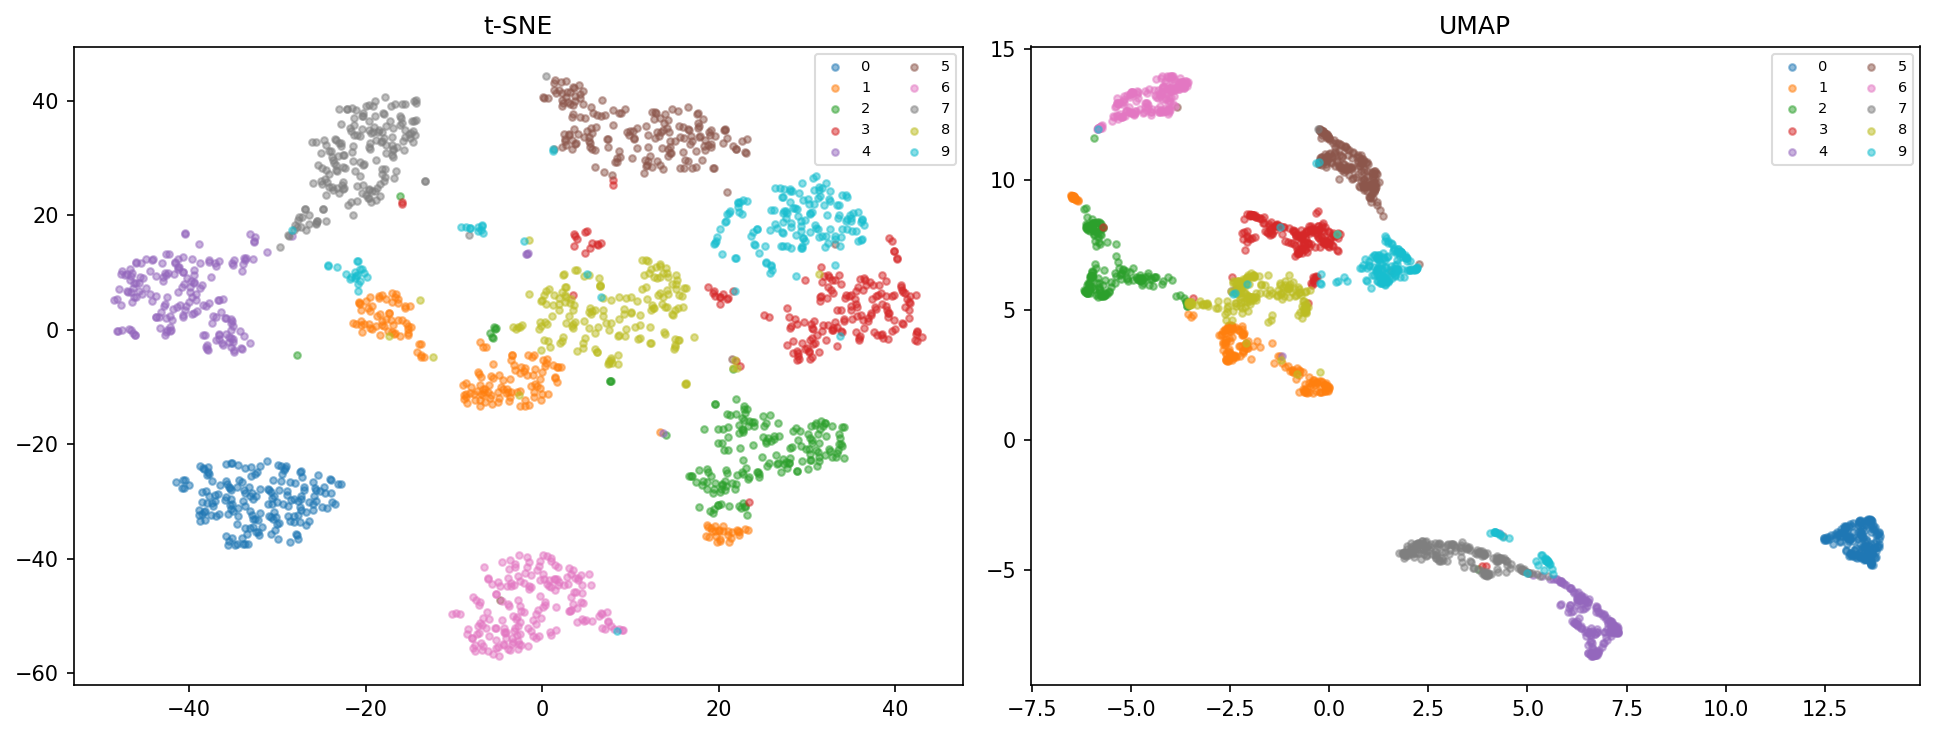

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for digit in range(10):
    mask = y_digits == digit
    axes[0].scatter(Z_tsne_digits[mask,0], Z_tsne_digits[mask,1], s=10, alpha=0.5, label=str(digit))
    axes[1].scatter(Z_umap_digits[mask,0], Z_umap_digits[mask,1], s=10, alpha=0.5, label=str(digit))

axes[0].set_title("t-SNE"); axes[1].set_title("UMAP")

for ax in axes:
    ax.legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.7)

plt.tight_layout()

plt.show()

### UMAP vs t-SNE

UMAP typically runs faster, preserves more *global* structure, and has two knobs: `n_neighbors` and `min_dist`. Neither gives a "correct" picture. Both are useful for discovering local structure.

### How to read embedding plots without fooling yourself

- **Nearby points are probably really neighbors.** Both methods optimize for this.
- **Far-apart points might or might not be far apart.** Global distances not preserved.
- **Cluster size is an artifact.**
- **Run it twice with different seeds.** If structure changes, it's not reliable.
- **Compare to PCA.** If PCA shows the same pattern, you can be more confident.

### Your turn!

1. Run t-SNE with perplexity 5, 30, 100. How does the embedding change?
2. If UMAP is available, try `n_neighbors=5` vs 50.
3. Why run PCA to 30D *before* t-SNE?

---

# Part II — Clustering: Grouping Without Labels

An embedding compresses each point into lower-dimensional coordinates. Clustering goes further: it compresses each point into a **discrete label**.

Different algorithms encode different assumptions:

| Method | What counts as a cluster? |
|:---|:---|
| k-means | Spherical blobs of similar size |
| Hierarchical | Nested tree of merges |
| DBSCAN | Dense regions separated by sparse gaps |
| Gaussian mixture | Ellipsoidal distributions |

None is universally "best." Each makes a bet about the shape of your data.

## 2.1 k-means

k-means is probably the most widely used clustering algorithm. It's fast, easy to understand, and often a good starting point. But it comes with strong assumptions — it expects clusters that are roughly spherical and roughly equal in size — and when those assumptions fail, it can give misleading results. Let's see how it works and where it breaks.

### The objective

What does k-means actually optimize? Given $n$ data points and $K$ clusters, it looks for assignments $c_i \in \{1, \dots, K\}$ and centers $\mu_1, \dots, \mu_K$ that minimize the total squared distance from each point to its assigned center:

$$
J = \sum_{i=1}^n \|x_i - \mu_{c_i}\|_2^2.
$$

This is called **inertia** or the within-cluster sum of squares.

Why squared distance? It penalizes large deviations heavily — a point 10 units from its center contributes 100 to $J$, not 10. This pulls clusters toward compact, roughly spherical shapes.

Why does the *mean* show up as the optimal center? Suppose we fix the assignments and ask: for cluster $C$, what $\mu$ minimizes $\sum_{i \in C} \|x_i - \mu\|^2$? Take the derivative, set to zero:

$$
\frac{\partial}{\partial \mu} \sum_{i \in C} \|x_i - \mu\|^2 = -2\sum_{i \in C}(x_i - \mu) = 0 \quad \Rightarrow \quad \mu = \frac{1}{|C|}\sum_{i \in C} x_i.
$$

The optimal center is the average. That's why it's called k-*means*.

### Lloyd's algorithm

The optimization problem — minimize $J$ over both assignments and centers — is NP-hard in general. But there's a simple iterative algorithm that works well in practice:

1. **Initialize** $K$ centers (randomly, or using k-means++).
2. **Assign** each point to its nearest center: $c_i \leftarrow \arg\min_k \|x_i - \mu_k\|^2$.
3. **Update** each center to the mean of its assigned points: $\mu_k \leftarrow \frac{1}{|C_k|}\sum_{i \in C_k} x_i$.
4. Repeat steps 2–3 until the assignments stop changing.

Why does this work? Each step can only decrease $J$ (or leave it the same). The assign step finds the best assignments for the current centers. The update step finds the best centers for the current assignments. Since $J$ is bounded below by zero and decreases at every step, the algorithm must converge.

The catch: it converges to a **local minimum**, which might not be the global one. Different random initializations can give different clusterings. That's why we run it multiple times (`n_init`) and keep the result with the lowest $J$.

In [36]:
x_tiny = np.array([0.0, 1.0, 2.0, 10.0, 11.0])
def kmeans_obj_1d(x, assignment):
    J = 0.0
    for k in set(assignment):
        pts = x[np.array(assignment) == k]
        J += np.sum((pts - pts.mean())**2)
    return float(J)

print(f"Good split [0,0,0,1,1]: J = {kmeans_obj_1d(x_tiny, [0,0,0,1,1]):.1f}")
print(f"Bad split  [0,0,1,1,1]: J = {kmeans_obj_1d(x_tiny, [0,0,1,1,1]):.1f}")

Good split [0,0,0,1,1]: J = 2.5
Bad split  [0,0,1,1,1]: J = 49.2


The bad split puts 2.0 with 10.0 and 11.0 — big squared-distance penalty.

In [37]:
def kmeans_from_scratch(X, K, n_init=10, max_iter=100, tol=1e-6, random_state=0):
    """k-means via Lloyd's algorithm, from scratch."""
    X = np.asarray(X, dtype=float); n, p = X.shape
    rng = np.random.default_rng(random_state)
    best = {"inertia": np.inf}
    for _ in range(n_init):
        centers = X[rng.choice(n, K, replace=False)].copy()
        for it in range(max_iter):
            labels = np.argmin(cdist(X, centers, "sqeuclidean"), axis=1)
            new_centers = np.empty_like(centers)
            for k in range(K):
                members = X[labels == k]
                new_centers[k] = members.mean(0) if len(members) else X[rng.integers(n)]
            if np.sqrt(np.sum((new_centers - centers)**2)) < tol: break
            centers = new_centers
        inertia = float(np.sum(np.min(cdist(X, centers, "sqeuclidean"), axis=1)))
        if inertia < best["inertia"]:
            best = {"labels": labels.copy(), "centers": centers.copy(),
                    "inertia": inertia, "n_iter": it+1}
    return best

In [38]:
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, n_features=2,
                              cluster_std=[1.0, 1.3, 0.9, 1.1], random_state=2)
X_blobs_std = StandardScaler().fit_transform(X_blobs)
result = kmeans_from_scratch(X_blobs_std, K=4, n_init=20, random_state=SEED)
labels_scratch = result["labels"]

km_sk = KMeans(n_clusters=4, n_init=20, random_state=0)
labels_sk = km_sk.fit_predict(X_blobs_std)
print(f"Inertia — scratch: {result['inertia']:.1f}, sklearn: {km_sk.inertia_:.1f}")
print(f"ARI(scratch vs sklearn): {adjusted_rand_score(labels_scratch, labels_sk):.3f}")

Inertia — scratch: 101.3, sklearn: 101.3
ARI(scratch vs sklearn): 1.000


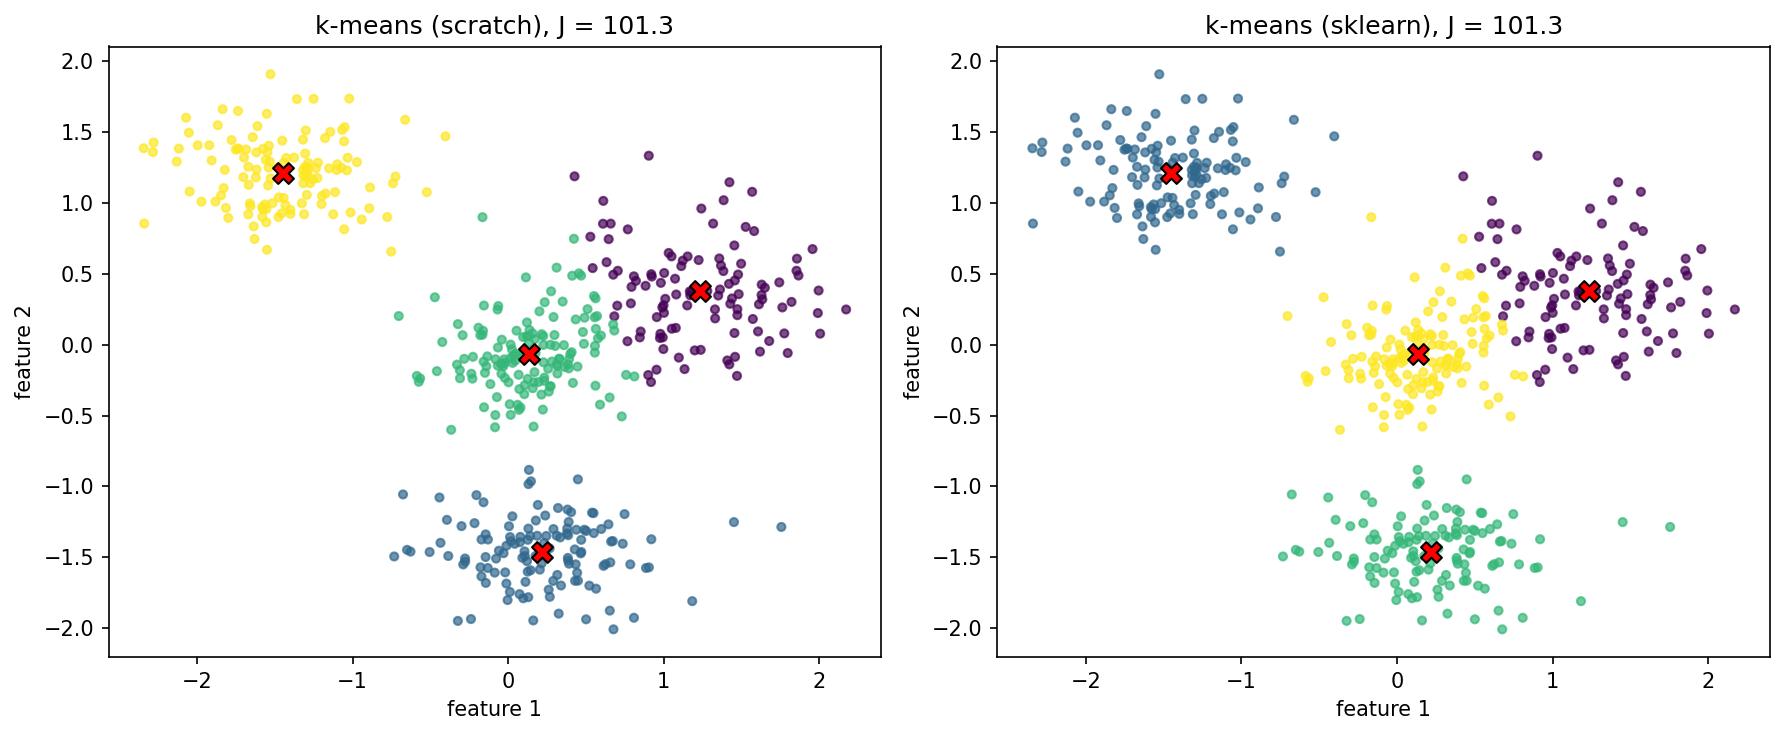

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].scatter(X_blobs_std[:,0], X_blobs_std[:,1], c=labels_scratch, s=15, alpha=0.7)
axes[0].scatter(*result["centers"].T, c="red", marker="X", s=100, edgecolors="black", zorder=5)
axes[0].set_title(f"k-means (scratch), J = {result['inertia']:.1f}")
axes[1].scatter(X_blobs_std[:,0], X_blobs_std[:,1], c=labels_sk, s=15, alpha=0.7)
axes[1].scatter(*km_sk.cluster_centers_.T, c="red", marker="X", s=100, edgecolors="black", zorder=5)
axes[1].set_title(f"k-means (sklearn), J = {km_sk.inertia_:.1f}")


for ax in axes:
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

plt.tight_layout()

plt.show()

### Choosing K

How many clusters should we use? This is one of the hardest questions in clustering, and there's no single right answer.

**The elbow plot.** Plot inertia $J$ vs. $K$. As $K$ increases, $J$ always goes down (at $K = n$, every point is its own cluster and $J = 0$). We look for a "bend" — a value of $K$ after which adding more clusters stops helping much.

**The silhouette score.** For each point $i$, the silhouette measures how well it fits its own cluster compared to the nearest alternative:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

where $a(i)$ is the mean distance from point $i$ to the other points in its cluster, and $b(i)$ is the mean distance to the points in the nearest *other* cluster. If $s(i) \approx 1$, the point is well inside its cluster. If $s(i) \approx 0$, it's on the boundary. If $s(i) < 0$, it might be in the wrong cluster.

We average $s(i)$ over all points. Higher is better. We look for the $K$ that maximizes this.

In [40]:
Ks = range(2, 9)
inertias, silhouettes = [], []
for K in Ks:
    km = KMeans(n_clusters=K, n_init=20, random_state=0)
    lab = km.fit_predict(X_blobs_std)
    inertias.append(km.inertia_); silhouettes.append(silhouette_score(X_blobs_std, lab))

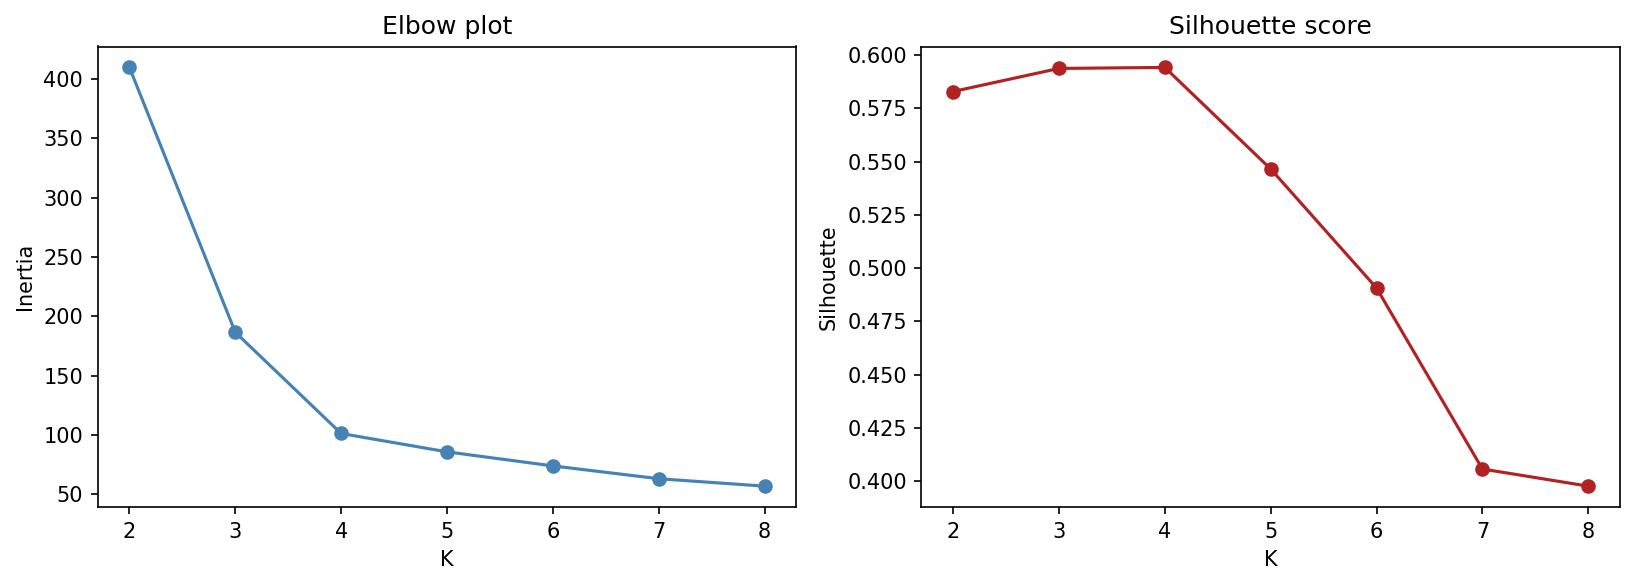

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(Ks), inertias, "o-", color="steelblue")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow plot")
axes[1].plot(list(Ks), silhouettes, "o-", color="firebrick")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()

On well-separated blobs, both agree: $K=4$. In practice, the signals are often muddier.

### What can go wrong: local minima

Lloyd's algorithm converges — but to a *local* minimum, not necessarily the global one. With bad initial centers, k-means can find a terrible partition. Let's see this directly.

In [42]:
# k-means with n_init=1 is a lottery — especially on harder data
X_hard, _ = make_blobs(n_samples=300, centers=5, n_features=2,
                       cluster_std=2.0, random_state=42)
X_hard_std = StandardScaler().fit_transform(X_hard)

inertias_1init = []
for seed in range(30):
    km_1 = KMeans(n_clusters=5, n_init=1, init="random", random_state=seed)
    km_1.fit(X_hard_std)
    inertias_1init.append(km_1.inertia_)

km_best = KMeans(n_clusters=5, n_init=30, random_state=0)
km_best.fit(X_hard_std)

print(f"n_init=1 (30 runs): inertia range [{min(inertias_1init):.1f}, {max(inertias_1init):.1f}]")
print(f"n_init=30:          inertia = {km_best.inertia_:.1f}")
pct = (max(inertias_1init) - min(inertias_1init)) / min(inertias_1init) * 100
print(f"Worst single run is {pct:.0f}% worse than the best.")
print("This is why we always run k-means multiple times.")

n_init=1 (30 runs): inertia range [61.7, 70.1]
n_init=30:          inertia = 61.7
Worst single run is 14% worse than the best.
This is why we always run k-means multiple times.


## 2.2 Hierarchical clustering: a tree of merges

k-means gives a flat partition — every point gets a label, and that's it. Hierarchical clustering gives a **tree** (dendrogram) showing how clusters merge as we relax the similarity threshold. You can cut the tree at any height to get a partition into $K$ clusters.

**Agglomerative** (bottom-up): start with each point as its own cluster. At each step, merge the two closest clusters. Repeat until everything is in one cluster.

But what does "closest" mean for two clusters? This is the **linkage** rule, and the choice changes the result:

- **Single linkage:** distance = closest pair of points between the two clusters. This tends to **chain** — it can merge long, stringy clusters one point at a time, which is sometimes correct (e.g., for elongated shapes) but often produces unbalanced trees.
- **Complete linkage:** distance = farthest pair of points. This tends to produce compact, roughly equal-sized clusters, but can split natural clusters that are slightly elongated.
- **Average linkage:** distance = average of all pairwise distances between points in the two clusters. A compromise.
- **Ward linkage:** merge the pair that increases the total within-cluster variance the least. This directly minimizes the same objective as k-means, but builds a tree instead of a flat partition. Often the best default.

Ward tends to produce the most interpretable dendrograms for data that's roughly blob-shaped. Single linkage is better for detecting unusual shapes.

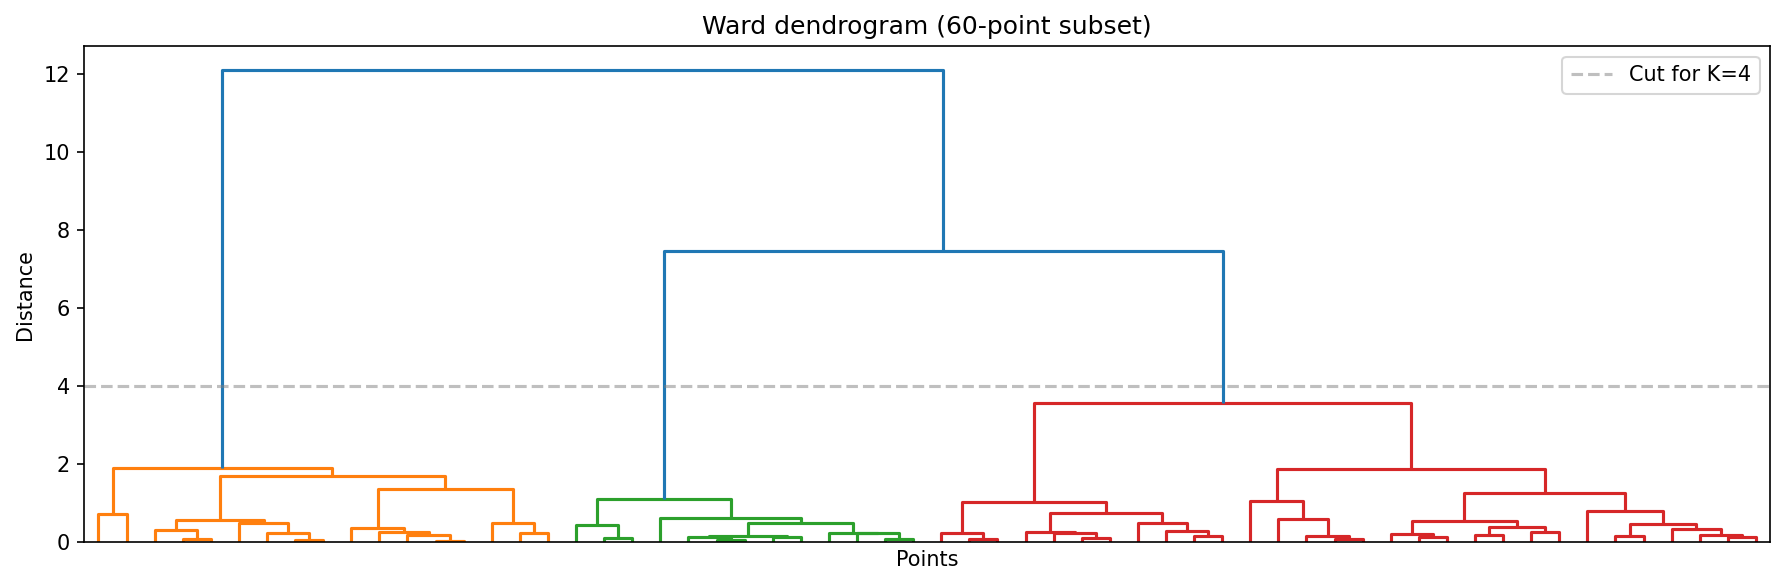

In [43]:
# ── Dendrogram on the blobs ──
# Use a random subset for readability
subset_idx = RNG.choice(X_blobs_std.shape[0], size=60, replace=False)
Z_link = linkage(X_blobs_std[subset_idx], method="ward")

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z_link, ax=ax, no_labels=True, color_threshold=4)
ax.set_title("Ward dendrogram (60-point subset)")
ax.set_xlabel("Points")
ax.set_ylabel("Distance")
ax.axhline(4, ls="--", color="gray", alpha=0.5, label="Cut for K=4")
ax.legend()
plt.tight_layout()
plt.show()

ARI(Ward vs k-means): 0.866


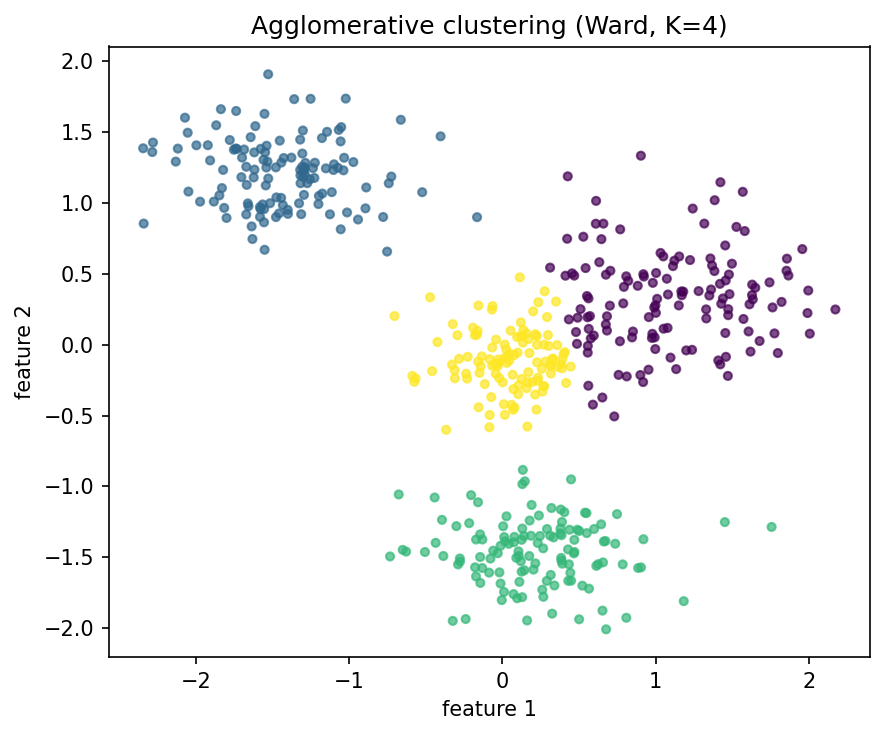

In [44]:
# ── Agglomerative clustering (Ward) on full data ──
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_blobs_std)

print(f"ARI(Ward vs k-means): {adjusted_rand_score(labels_sk, labels_agg):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_blobs_std[:, 0], X_blobs_std[:, 1], c=labels_agg, s=15, alpha=0.7)
ax.set_title("Agglomerative clustering (Ward, K=4)")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

On spherical blobs, Ward and k-means agree closely. The dendrogram's advantage is that it shows the *hierarchy* — which clusters are more closely related. That's useful when you care about nested structure (e.g., "are these two playing styles more similar to each other than to a third?").

## 2.3 DBSCAN: density-based clustering

k-means assumes spherical clusters. What if your clusters look like crescents or spirals?

**DBSCAN** defines clusters as *dense regions* separated by *sparse gaps*. Two parameters:
- $\varepsilon$ (**eps**): neighborhood radius.
- **min_samples**: how many neighbors a point needs to be considered "dense."

The algorithm works in three steps:

1. **Find core points.** A point is a core point if it has at least `min_samples` neighbors within distance $\varepsilon$. These are points in the dense interior of a cluster.
2. **Grow clusters.** Start from any unvisited core point. Add all its $\varepsilon$-neighbors to the cluster. For each of *those* that is also a core point, add *their* neighbors too. Keep growing until no more core points can be reached. This is basically a flood-fill on the $\varepsilon$-neighborhood graph.
3. **Label the rest.** Non-core points within $\varepsilon$ of a cluster are "border" points (assigned to that cluster but can't grow it further). Points not near any cluster are **noise** (label $-1$).

The result: clusters can be any shape, because they're defined by density, not by distance to a center. And you don't need to specify $K$ — the algorithm finds however many dense regions exist.

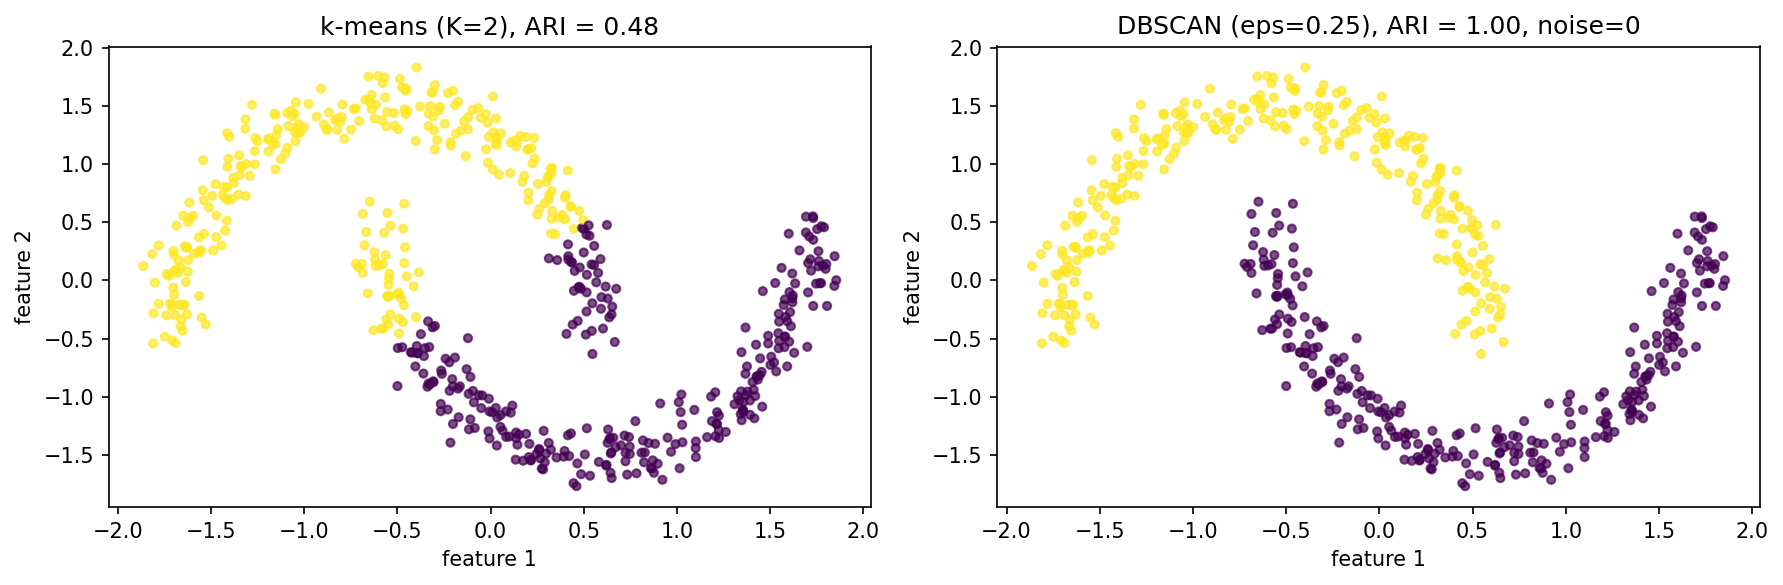

In [45]:
# ── DBSCAN vs k-means on two moons ──
X_moons, y_moons = make_moons(n_samples=600, noise=0.07, random_state=0)
X_moons_std = StandardScaler().fit_transform(X_moons)

km_moons = KMeans(n_clusters=2, n_init=20, random_state=0)
lab_km_moons = km_moons.fit_predict(X_moons_std)

db = DBSCAN(eps=0.25, min_samples=10)
lab_db = db.fit_predict(X_moons_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons_std[:, 0], X_moons_std[:, 1], c=lab_km_moons, s=15, alpha=0.7)
axes[0].set_title(f"k-means (K=2), ARI = {adjusted_rand_score(y_moons, lab_km_moons):.2f}")

colors_db = np.where(lab_db == -1, "gray", lab_db.astype(str))
axes[1].scatter(X_moons_std[:, 0], X_moons_std[:, 1], c=lab_db, s=15, alpha=0.7)
n_noise = (lab_db == -1).sum()
axes[1].set_title(f"DBSCAN (eps=0.25), ARI = {adjusted_rand_score(y_moons, lab_db):.2f}, noise={n_noise}")

for ax in axes:
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

plt.tight_layout()
plt.show()

k-means draws a straight line through the moons — it can't handle the curved geometry. DBSCAN follows the density and separates them cleanly.

The catch: choosing `eps` and `min_samples` requires judgment. Too small an `eps` and everything becomes noise; too large and the clusters merge.

What can go wrong? If your clusters have very different densities, no single `eps` works for all of them. The tight cluster needs a small `eps`, the loose one needs a large `eps`, and DBSCAN can't do both at once. That's where HDBSCAN comes in — it adapts the density threshold locally.

## 2.4 Gaussian mixture models: soft clustering

k-means gives a **hard** assignment: each point belongs to exactly one cluster. But real data often has ambiguous points near cluster boundaries.

A **Gaussian Mixture Model** (GMM) models the data as a mixture of $K$ Gaussian distributions:

$$
p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

- $\pi_k$ is the mixing weight of component $k$ ($\sum_k \pi_k = 1$).
- $\mu_k$ is the mean, $\Sigma_k$ is the covariance matrix.
- Each component can be an ellipsoid (not just a sphere).

### Fitting a GMM: the EM algorithm

We can't just run k-means here — we need to estimate means, covariances, and mixing weights simultaneously, and we want soft assignments. The **EM algorithm** (Dempster, Laird, Rubin, 1977) handles this by alternating two steps:

**E-step (Expectation):** Given the current parameter estimates, compute for each point $x_i$ the probability that it came from each component $k$:

$$
r_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}
$$

These $r_{ik}$ are called **responsibilities** — they're the soft assignments. A point near the boundary between two Gaussians will have $r_{ik} \approx 0.5$ for both.

**M-step (Maximization):** Given the responsibilities, update the parameters. Each center $\mu_k$ becomes a weighted average of all points, weighted by $r_{ik}$. Each covariance $\Sigma_k$ becomes a weighted covariance. Each mixing weight $\pi_k$ becomes the average responsibility.

Why does this work? Each iteration is guaranteed to increase (or maintain) the log-likelihood of the data. The E-step asks "given where the Gaussians are, which points belong to which?" The M-step asks "given those assignments, where should the Gaussians be?" It's the same assign-then-update logic as k-means, but with soft assignments and full covariance estimation.

ARI(GMM vs k-means): 0.944

Soft assignments for point 0: [0.    0.    0.996 0.004]
Max probability: 0.996


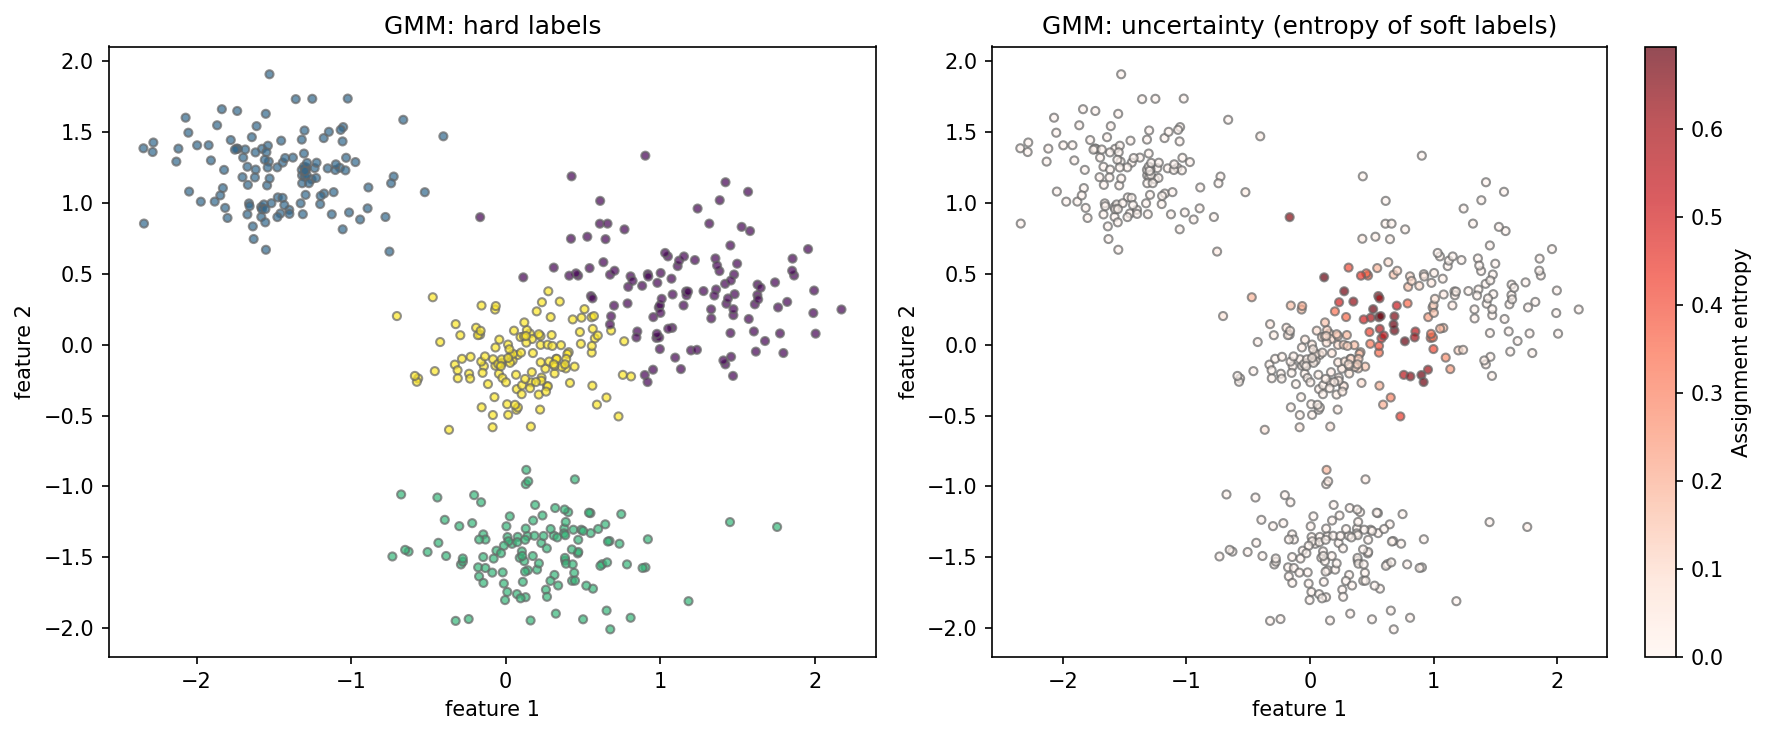

In [46]:
# ── GMM on the blobs ──
gmm = GaussianMixture(n_components=4, covariance_type="full", random_state=0)
gmm.fit(X_blobs_std)

lab_gmm = gmm.predict(X_blobs_std)
prob_gmm = gmm.predict_proba(X_blobs_std)

print(f"ARI(GMM vs k-means): {adjusted_rand_score(labels_sk, lab_gmm):.3f}")
print(f"\nSoft assignments for point 0: {np.round(prob_gmm[0], 3)}")
print(f"Max probability: {prob_gmm[0].max():.3f}")

# Show entropy of assignments (uncertainty)
entropy = -np.sum(prob_gmm * np.log(prob_gmm + 1e-15), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_blobs_std[:, 0], X_blobs_std[:, 1], c=lab_gmm, s=15, alpha=0.7, ec='.4')
axes[0].set_title("GMM: hard labels")

sc = axes[1].scatter(X_blobs_std[:, 0], X_blobs_std[:, 1], c=entropy, s=15, alpha=0.7, cmap="Reds", ec='.4')
plt.colorbar(sc, ax=axes[1], label="Assignment entropy")
axes[1].set_title("GMM: uncertainty (entropy of soft labels)")

for ax in axes:
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

plt.tight_layout()
plt.show()

Notice: the highest-entropy points are at the boundaries between clusters. That's where soft assignments add the most information over hard k-means labels.

### Model selection for GMMs: BIC

How many Gaussian components should we use? More components always fit the data better (more parameters = better fit), but at some point we're just fitting noise.

The **Bayesian Information Criterion** balances these:

$$
\mathrm{BIC} = -2\ln(L) + m \ln(n)
$$

where $L$ is the maximized likelihood, $m$ is the number of free parameters, and $n$ is the number of data points. The first term rewards good fit; the second penalizes complexity. Lower BIC is better.

As we increase $K$, the likelihood improves but the penalty grows. The BIC minimum tells us where the tradeoff is best.

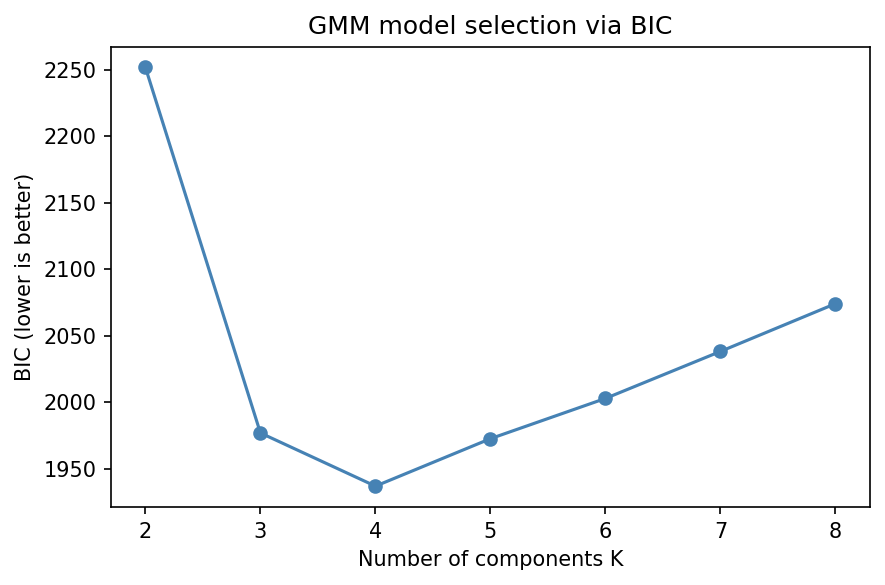

In [47]:
# ── BIC for different numbers of components ──
bics = []
for K in range(2, 9):
    g = GaussianMixture(n_components=K, covariance_type="full", random_state=0)
    g.fit(X_blobs_std)
    bics.append((K, g.bic(X_blobs_std)))

bic_df = pd.DataFrame(bics, columns=["K", "BIC"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bic_df["K"], bic_df["BIC"], "o-", color="steelblue")
ax.set_xlabel("Number of components K")
ax.set_ylabel("BIC (lower is better)")
ax.set_title("GMM model selection via BIC")
plt.tight_layout()
plt.show()

## 2.5 Evaluating clusters

### Internal metrics (no ground truth needed)

| Metric | Idea | Range | Better |
|:---|:---|:---|:---|
| **Silhouette** | How close is each point to its cluster vs. the nearest other cluster | $[-1, 1]$ | Higher |
| **Davies-Bouldin** | Average ratio of within-cluster spread to between-cluster distance | $[0, \infty)$ | Lower |
| **Calinski-Harabasz** | Ratio of between-cluster to within-cluster variance | $[0, \infty)$ | Higher |

### External metrics (require ground truth labels)

| Metric | Idea | Range | Better |
|:---|:---|:---|:---|
| **Adjusted Rand Index (ARI)** | Fraction of pairs correctly clustered together / apart, adjusted for chance | $[-1, 1]$ | Higher |
| **Normalized Mutual Info (NMI)** | Information shared between predicted and true labels, normalized | $[0, 1]$ | Higher |

A high silhouette score does not mean your clusters are "real" in any domain sense — it just means the data separates well under Euclidean distance. Always look at the actual cluster contents.

In [48]:
def report_clustering(X, labels, true_labels=None, name=""):
    """Print internal and (optionally) external clustering metrics."""
    n_clusters = len(set(labels) - {-1})
    n_noise = (np.array(labels) == -1).sum()
    print(f"--- {name} ---")
    print(f"  Clusters: {n_clusters}, Noise points: {n_noise}")

    if n_clusters >= 2:
        mask = np.array(labels) != -1
        print(f"  Silhouette:        {silhouette_score(X[mask], np.array(labels)[mask]):.3f}")
        print(f"  Davies-Bouldin:    {davies_bouldin_score(X[mask], np.array(labels)[mask]):.3f}")
        print(f"  Calinski-Harabasz: {calinski_harabasz_score(X[mask], np.array(labels)[mask]):.1f}")

    if true_labels is not None:
        print(f"  ARI: {adjusted_rand_score(true_labels, labels):.3f}")
        print(f"  NMI: {normalized_mutual_info_score(true_labels, labels):.3f}")
    print()

report_clustering(X_blobs_std, labels_sk, y_blobs, "k-means")
report_clustering(X_blobs_std, labels_agg, y_blobs, "Ward")
report_clustering(X_blobs_std, lab_gmm, y_blobs, "GMM")

--- k-means ---
  Clusters: 4, Noise points: 0
  Silhouette:        0.594
  Davies-Bouldin:    0.561
  Calinski-Harabasz: 1467.1
  ARI: 0.874
  NMI: 0.882

--- Ward ---
  Clusters: 4, Noise points: 0
  Silhouette:        0.572
  Davies-Bouldin:    0.554
  Calinski-Harabasz: 1385.7
  ARI: 0.901
  NMI: 0.903

--- GMM ---
  Clusters: 4, Noise points: 0
  Silhouette:        0.585
  Davies-Bouldin:    0.569
  Calinski-Harabasz: 1420.9
  ARI: 0.910
  NMI: 0.905



### Your turn!

1. Run DBSCAN on the blobs data. What `eps` and `min_samples` work? What happens if `eps` is too small?
2. Why does ARI adjust for chance? What would happen if you just used the raw Rand index?
3. Can internal metrics disagree? Try a dataset where silhouette prefers $K = 2$ but the true structure has $K = 4$.

---

# Part III — Case Study: World Cup Playing Styles

We have feature vectors for 32 World Cup teams. The workflow: standardize → embed (PCA) → choose $K$ → cluster → interpret → check stability.

In [49]:
# ── Step 1: Standardize (already done above, but let's be explicit) ──
print(f"Working with {X_teams_std.shape[0]} teams, {X_teams_std.shape[1]} features.")
print(f"Features: {feature_cols}")

Working with 32 teams, 14 features.
Features: ['passes_per90', 'shots_per90', 'carries_per90', 'dribbles_per90', 'ball_recoveries_per90', 'interceptions_per90', 'clearances_per90', 'fouls_per90', 'duels_per90', 'pass_completion', 'mean_pass_length', 'mean_xg_per_shot', 'mean_x_position', 'mean_carry_dist']


In [50]:
# ── Step 2: How many PCA components? ──
# Already computed above. Let's use 4 components for clustering (captures ~X% of variance)
n_comp_cluster = min(4, X_teams_std.shape[1])
Z_teams = Z_full[:, :n_comp_cluster]

print(f"Using {n_comp_cluster} PCA components")
print(f"Cumulative variance: {sum(pca_full.explained_variance_ratio_[:n_comp_cluster]):.1%}")

Using 4 PCA components
Cumulative variance: 78.2%


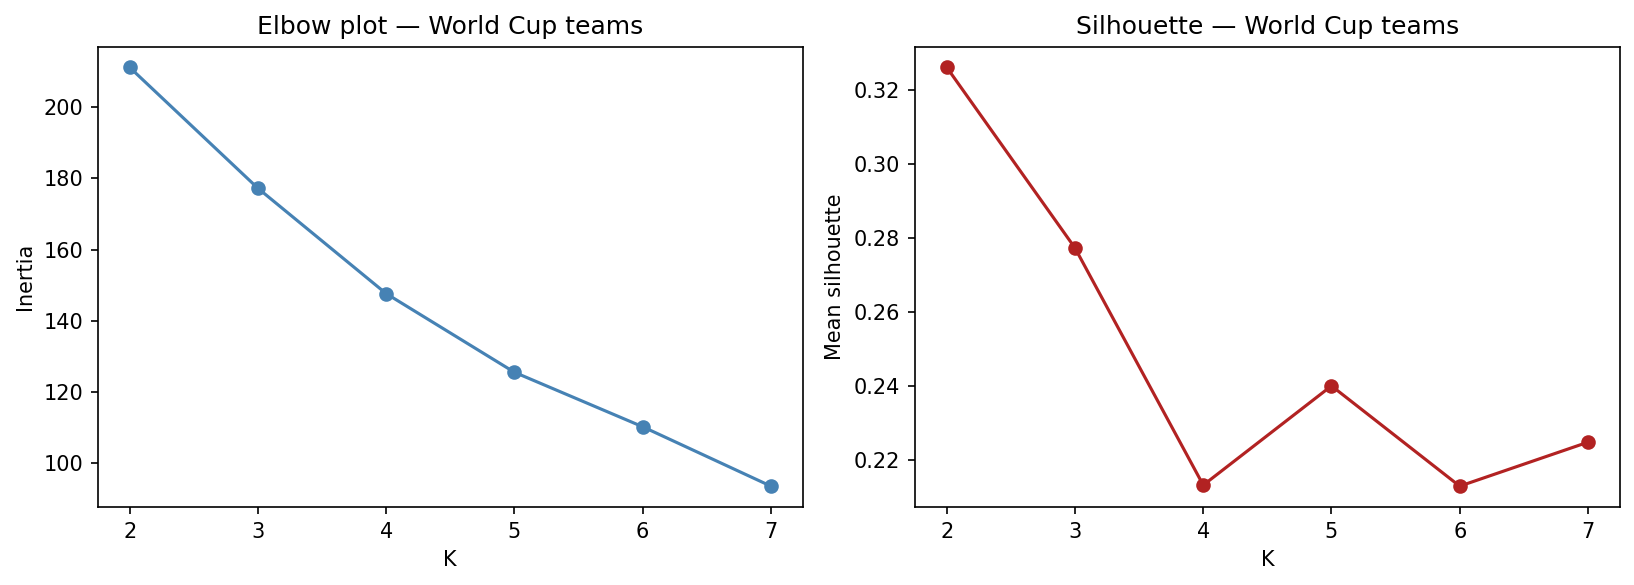

In [51]:
# ── Step 3: Cluster selection — elbow and silhouette ──
Ks_team = range(2, 8)
inertias_team = []
sil_team = []

for K in Ks_team:
    km = KMeans(n_clusters=K, n_init=30, random_state=SEED)
    lab = km.fit_predict(Z_teams)
    inertias_team.append(km.inertia_)
    sil_team.append(silhouette_score(Z_teams, lab))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(Ks_team), inertias_team, "o-", color="steelblue")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow plot — World Cup teams")

axes[1].plot(list(Ks_team), sil_team, "o-", color="firebrick")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Mean silhouette")
axes[1].set_title("Silhouette — World Cup teams")

plt.tight_layout()
plt.show()

In [52]:
# ── Cluster with the best K (pick from the plots above) ──
# We'll try K=3 and K=4 and compare

for K_try in [3, 4]:
    km_teams = KMeans(n_clusters=K_try, n_init=30, random_state=SEED)
    lab_teams = km_teams.fit_predict(Z_teams)

    # Show teams in each cluster
    print(f"\n=== K = {K_try} ===")
    for k in range(K_try):
        members = [team_names[i] for i in range(len(team_names)) if lab_teams[i] == k]
        print(f"  Cluster {k}: {', '.join(sorted(members))}")
    print(f"  Silhouette: {silhouette_score(Z_teams, lab_teams):.3f}")


=== K = 3 ===
  Cluster 0: Australia, Cameroon, Costa Rica, Ecuador, Ghana, Iran, Japan, Mexico, Morocco, Poland, Qatar, Saudi Arabia, Senegal, Serbia, South Korea, Tunisia, United States, Uruguay, Wales
  Cluster 1: Brazil, Canada, France, Germany, Spain
  Cluster 2: Argentina, Belgium, Croatia, Denmark, England, Netherlands, Portugal, Switzerland
  Silhouette: 0.277

=== K = 4 ===
  Cluster 0: Australia, Cameroon, Costa Rica, Ecuador, Poland, Qatar, Senegal, Serbia, South Korea, Uruguay, Wales
  Cluster 1: Ghana, Iran, Japan, Mexico, Morocco, Saudi Arabia, Tunisia
  Cluster 2: Brazil, Canada, France, Germany, Spain, United States
  Cluster 3: Argentina, Belgium, Croatia, Denmark, England, Netherlands, Portugal, Switzerland
  Silhouette: 0.213


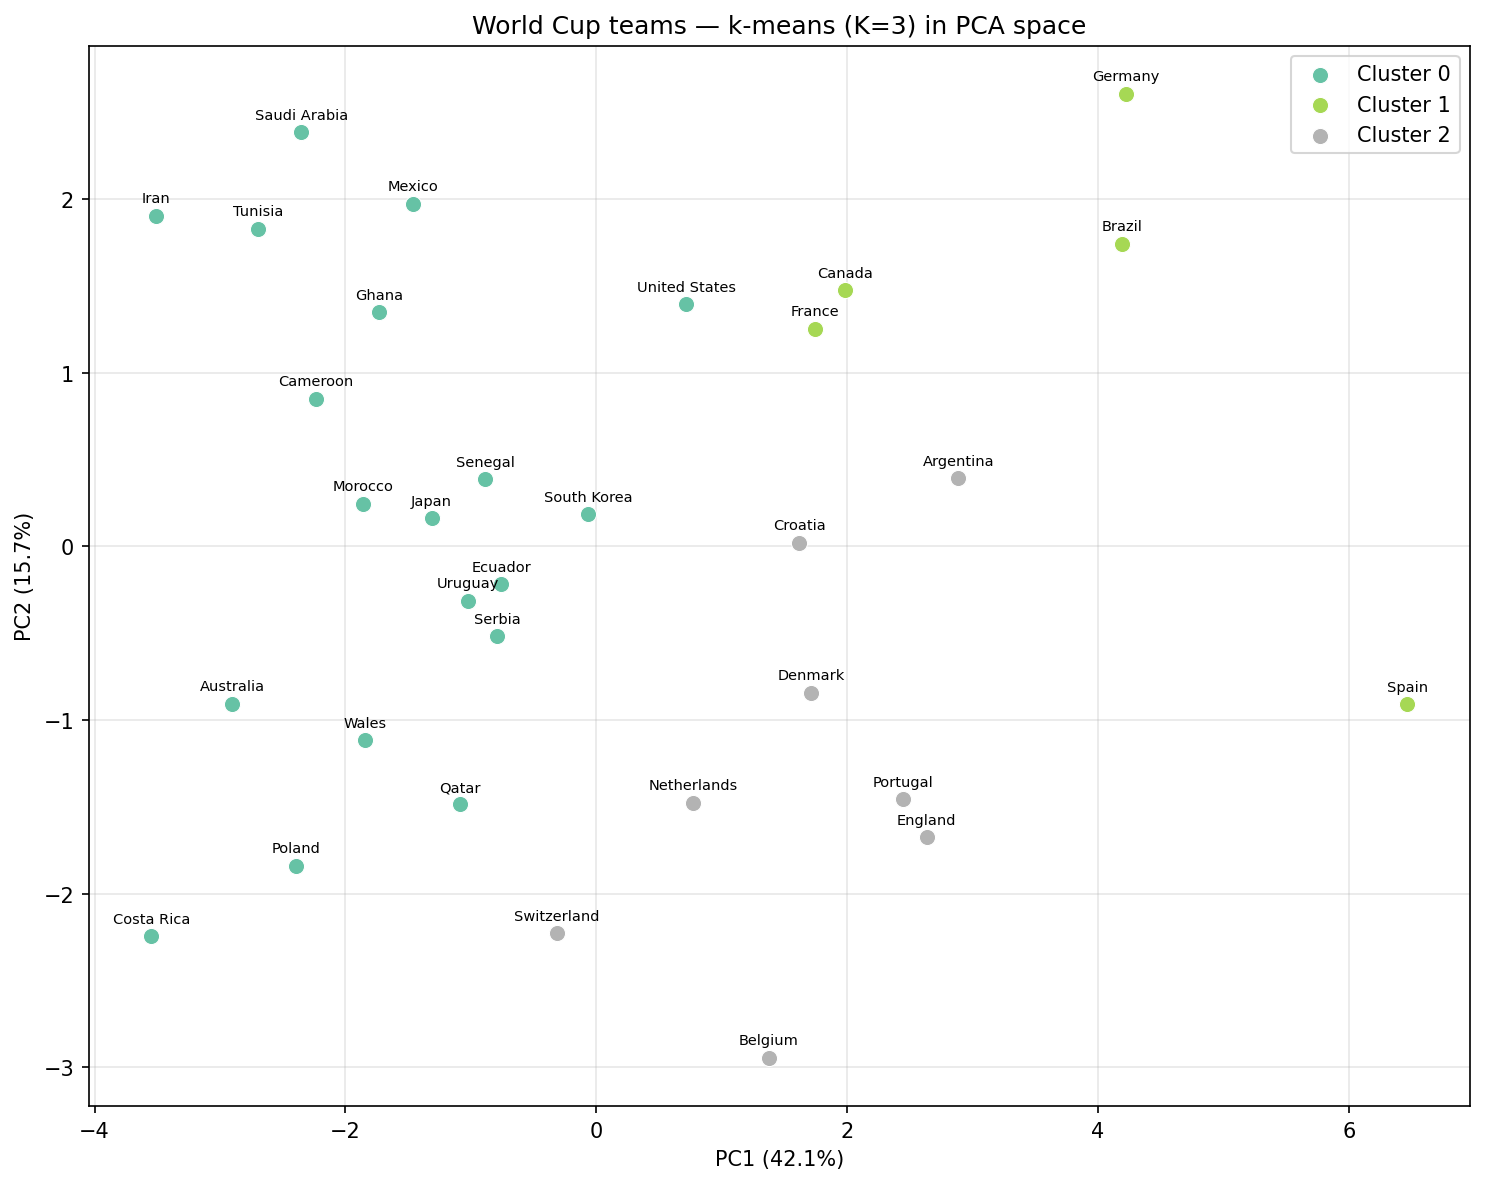

In [53]:
# ── Visualize clusters in PCA space ──
# Use the K that looked best above (let's default to 3)
K_best = 3
km_final = KMeans(n_clusters=K_best, n_init=30, random_state=SEED)
lab_final = km_final.fit_predict(Z_teams)

colors_cluster = plt.cm.Set2(np.linspace(0, 1, K_best))

fig, ax = plt.subplots(figsize=(10, 8))

for k in range(K_best):
    mask = lab_final == k
    ax.scatter(Z_full[mask, 0], Z_full[mask, 1],
               s=60, color=colors_cluster[k], edgecolors="white",
               linewidth=0.5, label=f"Cluster {k}", zorder=3)

for i, name in enumerate(team_names):
    ax.annotate(name, (Z_full[i, 0], Z_full[i, 1]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"World Cup teams — k-means (K={K_best}) in PCA space")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

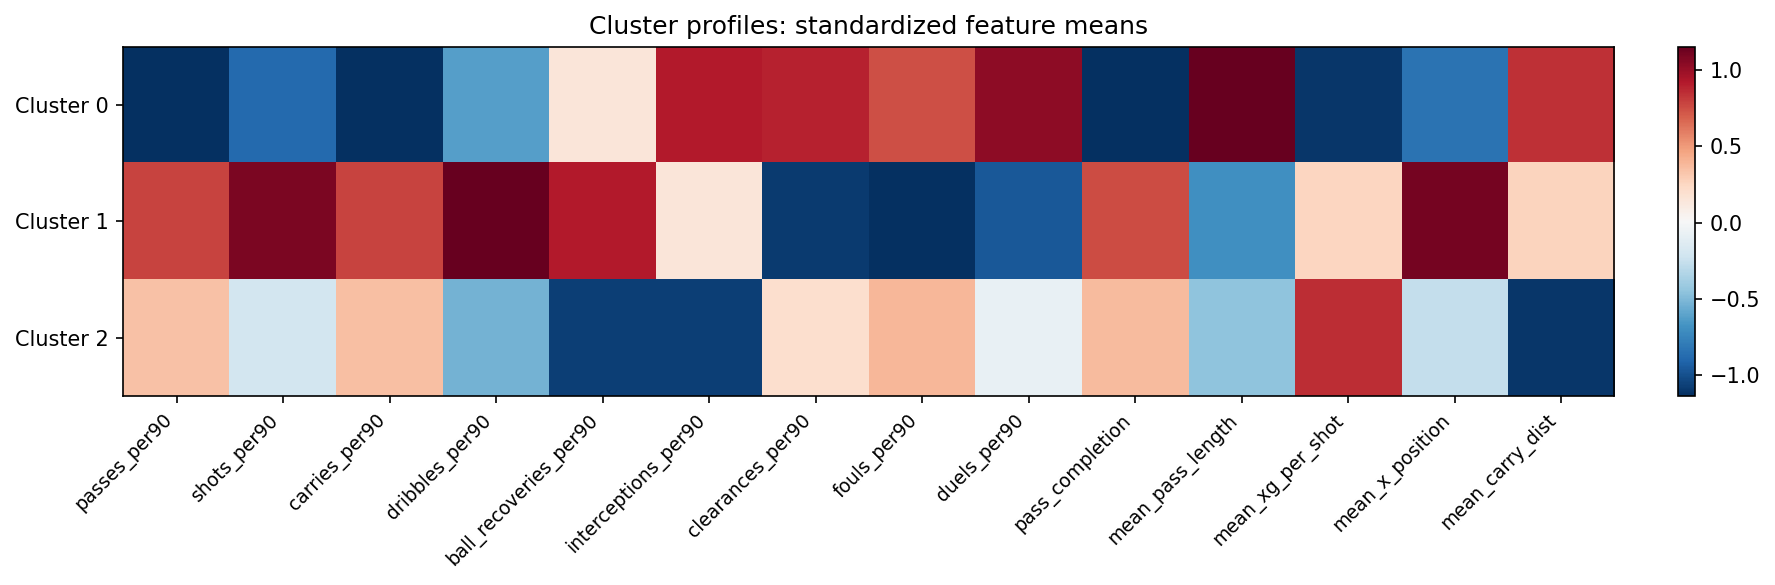


Cluster means (raw):


,passes_per90,shots_per90,carries_per90,dribbles_per90,ball_recoveries_per90,interceptions_per90,clearances_per90,fouls_per90,duels_per90,pass_completion,mean_pass_length,mean_xg_per_shot,mean_x_position,mean_carry_dist
cluster,,,,,,,,,,,,,,
0,443.12,9.72,332.95,12.40,46.55,11.19,23.85,14.38,36.31,0.78,22.25,0.10,55.79,5.85
1,671.31,16.41,546.08,20.70,50.12,10.58,13.23,11.52,30.09,0.86,20.13,0.13,61.36,5.70
2,618.98,12.02,498.06,12.81,40.98,9.62,20.14,13.83,32.83,0.84,20.41,0.14,57.43,5.34


In [54]:
# ── Interpret clusters: feature means ──
df_teams_clustered = features.copy()
df_teams_clustered["cluster"] = lab_final

cluster_means = df_teams_clustered.groupby("cluster")[feature_cols].mean()

# Show as a heatmap (standardized so we can compare across features)
cluster_means_std = (cluster_means - cluster_means.mean()) / cluster_means.std()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(cluster_means_std.values, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(K_best))
ax.set_yticklabels([f"Cluster {k}" for k in range(K_best)])
ax.set_title("Cluster profiles: standardized feature means")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

# Also print the raw means
print("\nCluster means (raw):")
cluster_means.round(2)

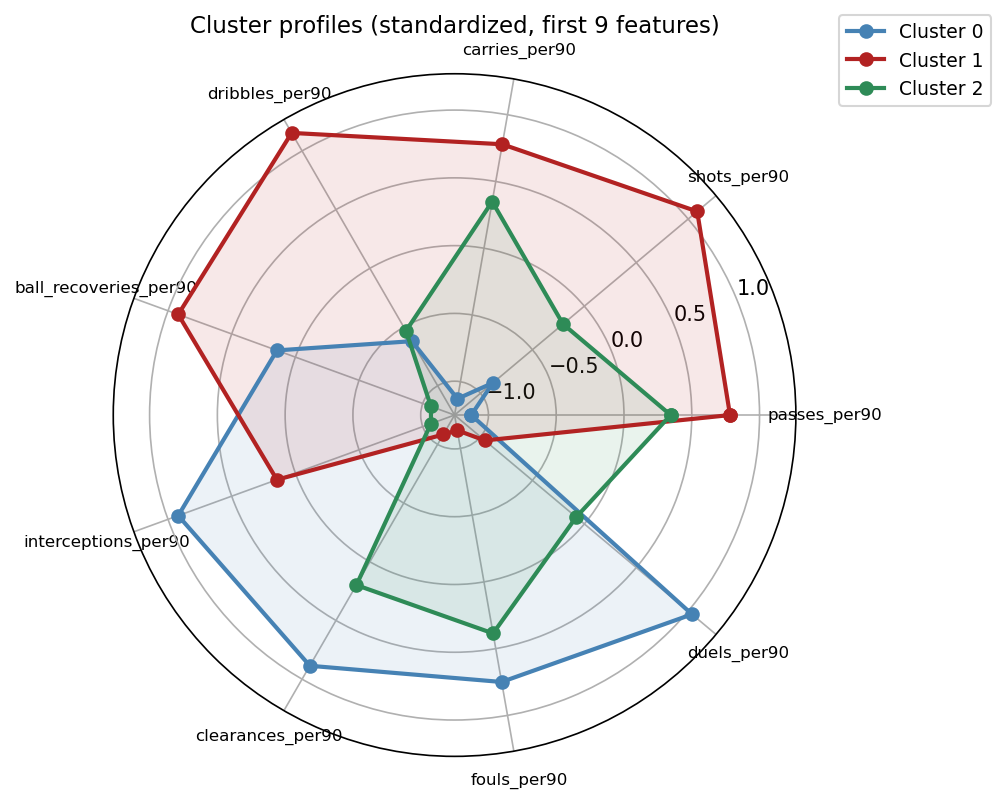

In [55]:
# ── Radar chart of cluster profiles ──
# Standardize cluster means for comparison
cm_z = (cluster_means[feature_cols[:9]] - cluster_means[feature_cols[:9]].mean()) / cluster_means[feature_cols[:9]].std()

categories = list(cm_z.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors_radar = ["steelblue", "firebrick", "seagreen", "darkorange"]

for k in range(K_best):
    values = cm_z.loc[k].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=f"Cluster {k}", color=colors_radar[k])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[k])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8)
ax.set_title("Cluster profiles (standardized, first 9 features)", fontsize=11, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the clusters

Cluster 1 is the **possession-dominant** group — Brazil, Canada, France, Germany, Spain. Highest passes per 90, highest pass completion, highest mean x position. These teams play high up the pitch and keep the ball. They also have the most carries and dribbles.

Cluster 2 is the **balanced/structured** group — Argentina, Belgium, Croatia, Denmark, England, Netherlands, Portugal, Switzerland. Moderate across the board, slightly higher shots per 90. These are teams with the talent and organization to compete deep into the tournament without relying on a single tactical identity.

Cluster 0 is the **direct/defensive** group — the largest cluster, mostly group-stage exits and underdogs. Lower pass rates, more clearances, lower mean x position. These teams spend more time in their own half and clear the ball rather than building from the back.

Does this pass the smell test? Mostly, yes. Spain and Germany in the same cluster as Brazil makes sense — all three are historically possession-oriented. Argentina and Croatia in the "balanced" group also feels right for teams that can adapt their style.

What doesn't fit? Canada is in the possession-dominant group, which might surprise you — but they played only 3 matches, all in the group stage, and their per-90 rates in that small sample happened to be high. Small sample sizes are a real hazard here.

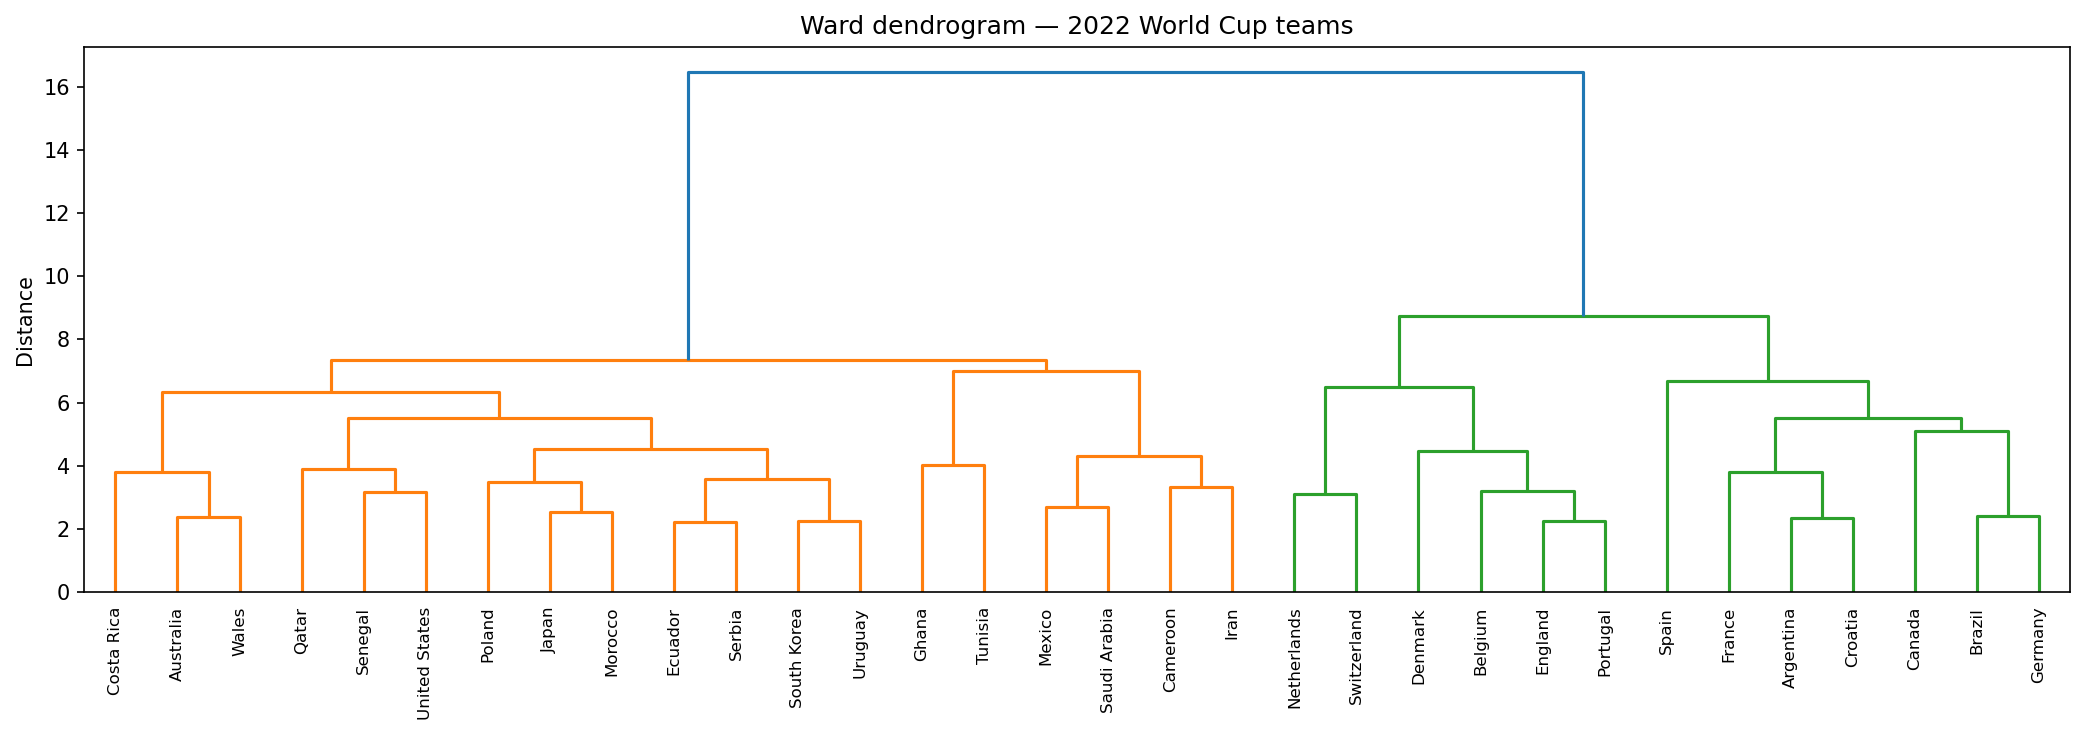

In [56]:
# ── Hierarchical clustering — Ward dendrogram of all 32 teams ──
Z_ward_teams = linkage(X_teams_std, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_ward_teams, ax=ax, labels=team_names, leaf_rotation=90, leaf_font_size=8)
ax.set_title("Ward dendrogram — 2022 World Cup teams")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

The dendrogram gives a richer picture than a flat partition. Which teams are most similar? Which pairs get merged last? The tree shows the full hierarchy of similarity.

### GMM on the teams

In [57]:
# ── GMM with soft assignments ──
gmm_teams = GaussianMixture(n_components=K_best, covariance_type="full", random_state=SEED)
gmm_teams.fit(Z_teams)

lab_gmm_teams = gmm_teams.predict(Z_teams)
prob_gmm_teams = gmm_teams.predict_proba(Z_teams)

# Show the most ambiguous teams (highest entropy)
entropy_teams = -np.sum(prob_gmm_teams * np.log(prob_gmm_teams + 1e-15), axis=1)
ambig_order = np.argsort(entropy_teams)[::-1]

print("Most ambiguous teams (highest assignment entropy):")
for idx in ambig_order[:8]:
    probs_str = ", ".join([f"C{k}:{prob_gmm_teams[idx, k]:.2f}" for k in range(K_best)])
    print(f"  {team_names[idx]:20s}  entropy={entropy_teams[idx]:.3f}  [{probs_str}]")

Most ambiguous teams (highest assignment entropy):
  United States         entropy=0.629  [C0:0.00, C1:0.32, C2:0.68]
  South Korea           entropy=0.373  [C0:0.00, C1:0.88, C2:0.12]
  Ecuador               entropy=0.254  [C0:0.00, C1:0.93, C2:0.07]
  Serbia                entropy=0.147  [C0:0.00, C1:0.97, C2:0.03]
  Qatar                 entropy=0.100  [C0:0.00, C1:0.98, C2:0.02]
  Switzerland           entropy=0.089  [C0:0.00, C1:0.02, C2:0.98]
  Japan                 entropy=0.072  [C0:0.00, C1:0.99, C2:0.01]
  Belgium               entropy=0.044  [C0:0.00, C1:0.01, C2:0.99]


The soft assignments reveal which teams are between styles. A team with 55% probability in one cluster and 40% in another is genuinely a hybrid — not a clear archetype. That's useful information that hard clustering throws away.

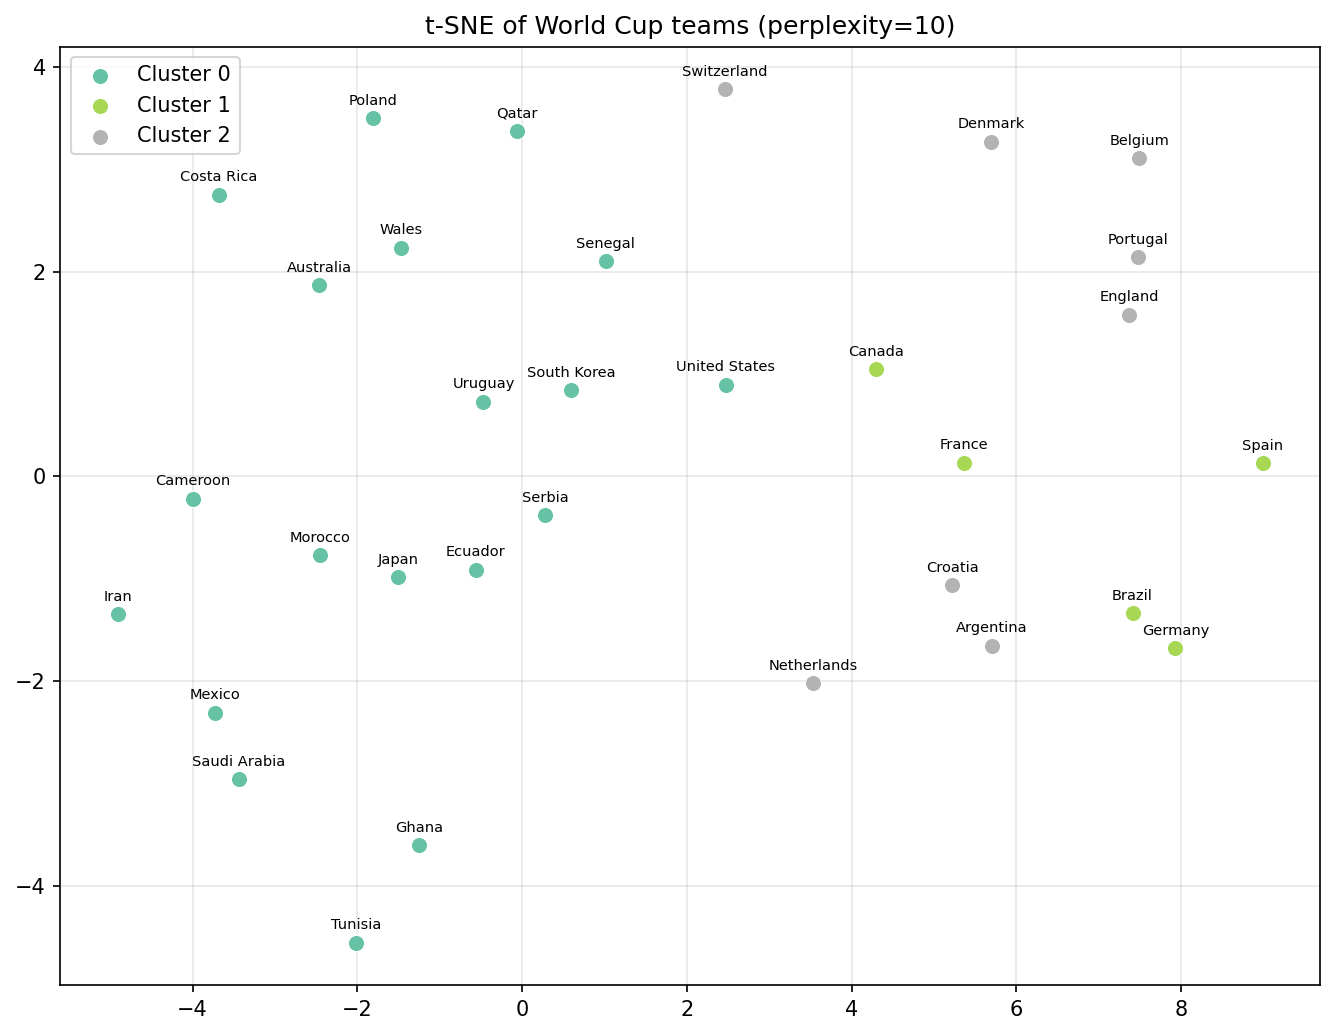

In [58]:
# ── t-SNE on teams (small dataset — use with caution) ──
# With only ~32 points, t-SNE is a stretch, but let's see what it does.

n_teams = X_teams_std.shape[0]
perp = min(10, n_teams - 1)  # perplexity must be < n

tsne_teams = TSNE(n_components=2, perplexity=perp, random_state=SEED, init="pca", learning_rate="auto")
Z_tsne_teams = tsne_teams.fit_transform(X_teams_std)

fig, ax = plt.subplots(figsize=(9, 7))
for k in range(K_best):
    mask = lab_final == k
    ax.scatter(Z_tsne_teams[mask, 0], Z_tsne_teams[mask, 1],
               s=60, color=colors_cluster[k], edgecolors="white",
               linewidth=0.5, label=f"Cluster {k}", zorder=3)

for i, name in enumerate(team_names):
    ax.annotate(name, (Z_tsne_teams[i, 0], Z_tsne_teams[i, 1]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.set_title(f"t-SNE of World Cup teams (perplexity={perp})")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

With only ~32 points, t-SNE is noisy and not very stable. PCA is actually the better embedding here — it's less prone to overfitting with small $n$. Use t-SNE when you have hundreds or thousands of points.

### Stability check: do the clusters change if we perturb the data?

In [59]:
# ── Bootstrap stability ──
# Repeat clustering on bootstrap resamples and check ARI with the original

n_boot = 50
ari_scores = []

for b in range(n_boot):
    boot_idx = RNG.choice(len(team_names), size=len(team_names), replace=True)
    Z_boot = Z_teams[boot_idx]
    km_boot = KMeans(n_clusters=K_best, n_init=20, random_state=b)
    lab_boot = km_boot.fit_predict(Z_boot)
    # Compare to original labels for the same points
    ari_scores.append(adjusted_rand_score(lab_final[boot_idx], lab_boot))

print(f"Bootstrap ARI: mean = {np.mean(ari_scores):.3f}, std = {np.std(ari_scores):.3f}")
print(f"Range: [{np.min(ari_scores):.3f}, {np.max(ari_scores):.3f}]")

Bootstrap ARI: mean = 0.588, std = 0.264
Range: [0.137, 1.000]


If the mean ARI is high (> 0.7), the clusters are reasonably stable. If it's low, the cluster boundaries are soft — small perturbations shuffle assignments. That's not necessarily bad, but it means you should treat the clusters as suggestive, not definitive.

### Your turn!

1. Try adding more features to the team vectors. Can you compute spatial features (e.g., fraction of passes in the final third)? Does this change the clustering?
2. Run the full pipeline on the 2018 World Cup (competition_id=43, season_id=3). Do the same style archetypes show up?
3. Instead of clustering *teams*, try clustering *individual possessions* by their event sequences. What kinds of possessions cluster together?

---

# Part IV — Clustering Digits: A Higher-Dimensional Case Study

The World Cup data had ~32 teams and ~14 features. Let's push the methods harder with a bigger dataset: 1,797 digit images in 64 dimensions.

In [60]:
# ── k-means on digits: raw space vs PCA space ──
K_digits = 10  # we know there are 10 digit classes

km_raw = KMeans(n_clusters=K_digits, n_init=30, random_state=0)
lab_raw = km_raw.fit_predict(X_digits_std)

X_pca30 = PCA(n_components=30, random_state=0).fit_transform(X_digits_std)
km_pca = KMeans(n_clusters=K_digits, n_init=30, random_state=0)
lab_pca = km_pca.fit_predict(X_pca30)

print("k-means on raw 64D:")
print(f"  ARI = {adjusted_rand_score(y_digits, lab_raw):.3f}")
print(f"  NMI = {normalized_mutual_info_score(y_digits, lab_raw):.3f}")
print()
print("k-means on PCA-30D:")
print(f"  ARI = {adjusted_rand_score(y_digits, lab_pca):.3f}")
print(f"  NMI = {normalized_mutual_info_score(y_digits, lab_pca):.3f}")

k-means on raw 64D:
  ARI = 0.468
  NMI = 0.626

k-means on PCA-30D:
  ARI = 0.477
  NMI = 0.632


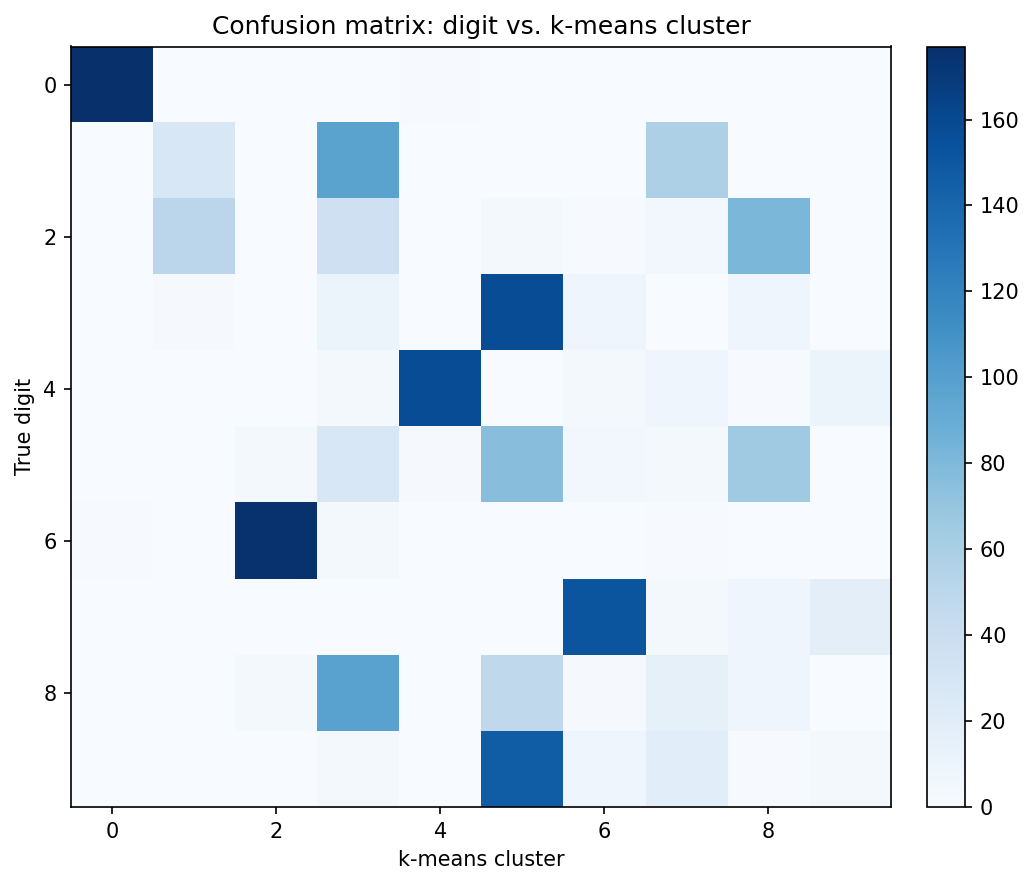

In [61]:
# ── Confusion matrix: true digit vs k-means cluster ──
cm = confusion_matrix(y_digits, lab_pca)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, aspect="auto", cmap="Blues")
ax.set_xlabel("k-means cluster")
ax.set_ylabel("True digit")
ax.set_title("Confusion matrix: digit vs. k-means cluster")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

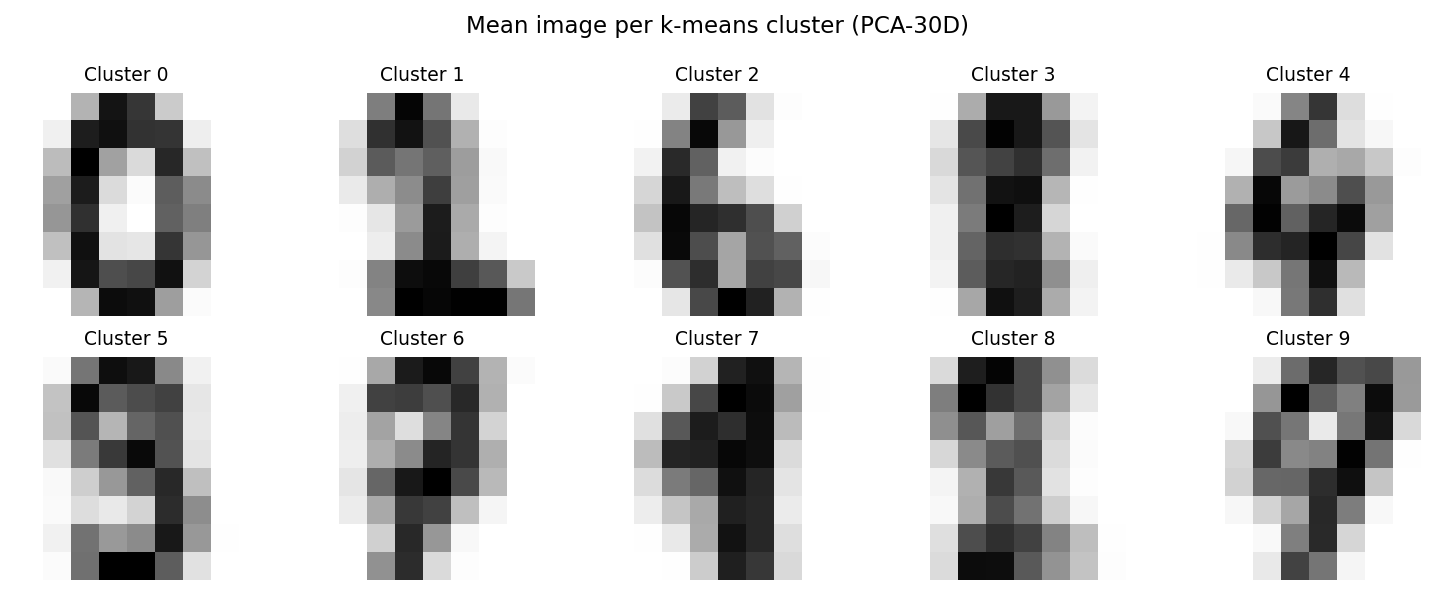

In [62]:
# ── Mean digit image per cluster ──
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for k, ax in enumerate(axes.ravel()):
    mean_img = images_digits[lab_pca == k].mean(axis=0)
    ax.imshow(mean_img, cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Cluster {k}", fontsize=9); ax.axis("off")
fig.suptitle("Mean image per k-means cluster (PCA-30D)", fontsize=11)
plt.tight_layout(); plt.show()

Most clusters clearly correspond to a single digit. The mean images show what the "typical" member of each cluster looks like. Where clusters fail (e.g., if 4 and 9 share a cluster), it's because those digits have similar pixel patterns.

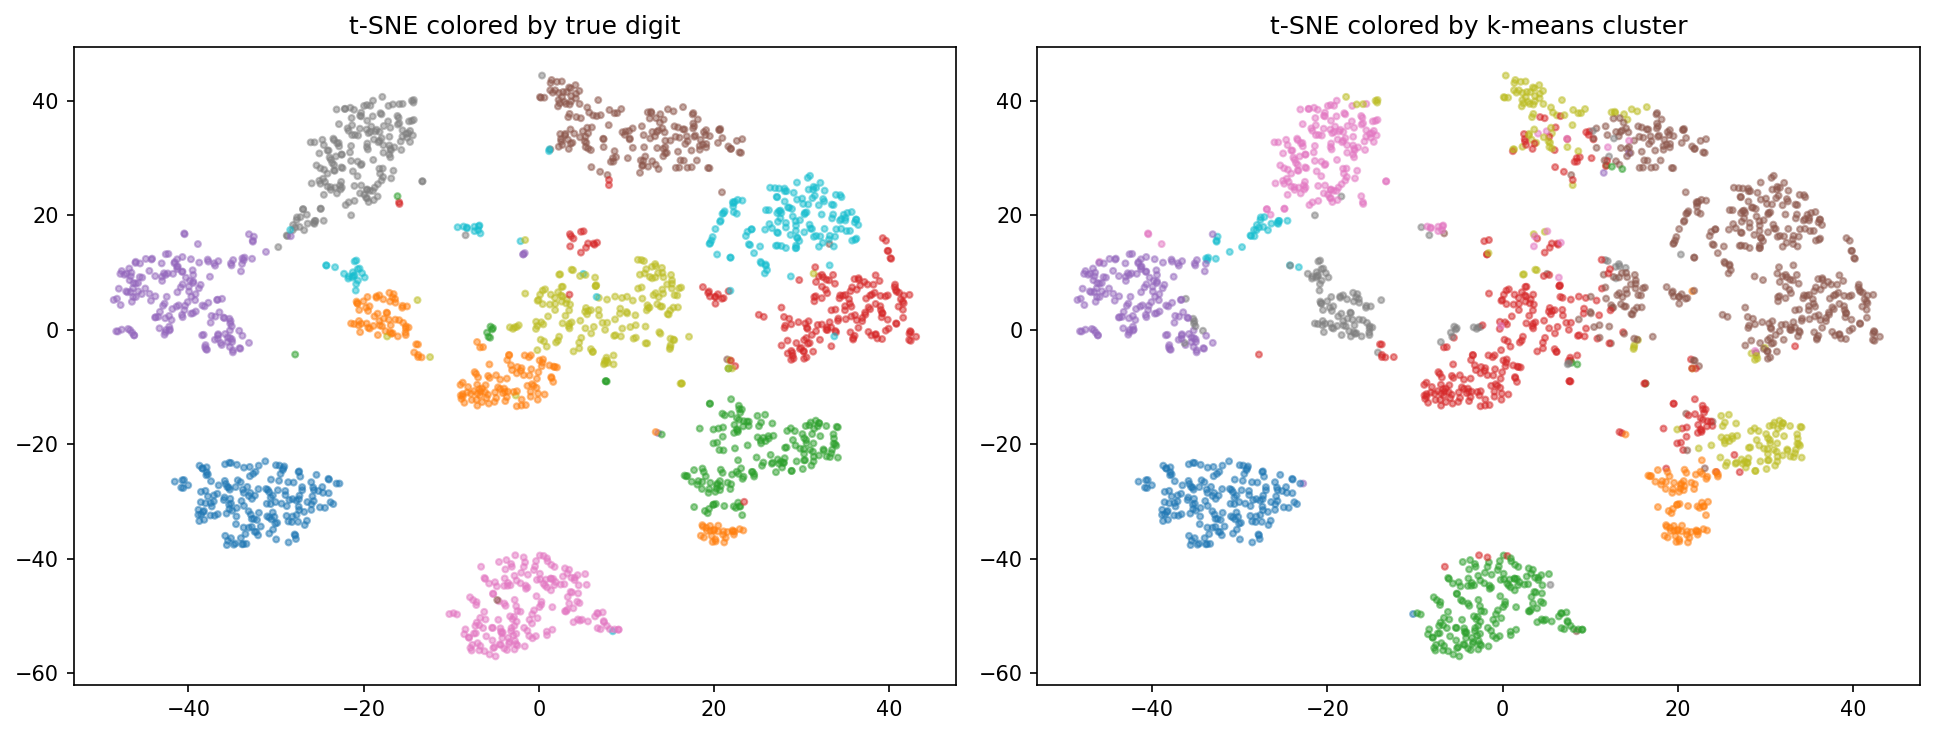

In [63]:
# ── k-means clusters overlaid on t-SNE ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(Z_tsne_digits[:, 0], Z_tsne_digits[:, 1], c=y_digits, s=8, alpha=0.5, cmap="tab10")
axes[0].set_title("t-SNE colored by true digit")

axes[1].scatter(Z_tsne_digits[:, 0], Z_tsne_digits[:, 1], c=lab_pca, s=8, alpha=0.5, cmap="tab10")
axes[1].set_title("t-SNE colored by k-means cluster")

plt.tight_layout()
plt.show()

The two colorings should look similar — where they disagree, you can see which digits k-means confuses.

---

# Pitfalls and Best Practices

### Representation dominates everything
Your features define the geometry. Different features lead to different distances, different clusters, different conclusions.

### Scale and outliers
Always ask: what are the units of each feature? Features with larger variance dominate PCA and k-means. Outliers can hijack entire principal components or cluster centers. Robust alternatives (robust scaling, trimmed k-means) exist.

### Don't over-interpret 2D embeddings
t-SNE and UMAP produce pretty pictures, but:
- Distances between clusters are not meaningful.
- Cluster sizes are not meaningful.
- Different random seeds give different layouts.
- Always run at least one linear baseline (PCA) before trusting a nonlinear story.

### Cluster metrics are not a substitute for thinking
Internal metrics can disagree with each other and with domain knowledge. A high silhouette score just means "well-separated under Euclidean distance." It doesn't mean the clusters correspond to anything real. Always inspect cluster contents: feature means, exemplar members, and stability.

### Choosing a pipeline
Common patterns that work well:
- Standardize → PCA (30–100 dims) → k-means
- Standardize → UMAP → HDBSCAN
- Standardize → PCA → GMM → inspect soft assignments

But always validate against your domain question. If a cluster doesn't make football sense, it might just be an artifact of your features.

### When the clusters aren't "real"
Sometimes the data is genuinely continuous — there are no discrete groups. k-means will still partition the data into $K$ groups, but those boundaries are arbitrary. Check by:
- Varying $K$ and seeing if the story changes dramatically.
- Looking at silhouette scores per point — lots of near-zero scores means weak structure.
- Using GMM soft assignments — if many points are 50/50, the boundary is fuzzy.

---

# Summary

**Embeddings** compress high-dimensional data into lower dimensions for visualization and downstream modeling. PCA is linear and variance-optimal. t-SNE and UMAP are nonlinear and optimize for local neighborhood preservation.

**Clustering** assigns discrete labels without supervision. k-means assumes spheres, hierarchical gives a tree, DBSCAN finds dense regions, GMM gives soft probabilities.

Both are hypotheses, not ground truth. Check stability, compare methods, inspect cluster contents, and tie the results back to a domain question.

---

# Appendices

## Appendix A: k-means++ initialization

Random initialization can go badly wrong. If two initial centers land in the same dense cluster by chance, that cluster gets split while another cluster gets no center at all. The algorithm converges to a local minimum that's far from optimal.

**k-means++** (Arthur & Vassilvitskii, 2007) fixes this with a simple idea: pick centers *sequentially*, where each new center is chosen with probability proportional to its squared distance from the nearest existing center. This spreads centers across the data.

The algorithm:

1. Pick the first center uniformly at random from the data.
2. For each remaining point $x$, compute $d(x)^2$ = squared distance to the nearest existing center.
3. Pick the next center with probability $\propto d(x)^2$.
4. Repeat until you have $K$ centers.
5. Run Lloyd's algorithm from there.

sklearn uses k-means++ by default (`init="k-means++"`). You almost never want `init="random"` in practice.

## Appendix B: Silhouette score from scratch

The silhouette score for point $i$ measures how well it fits its assigned cluster vs. the nearest alternative. Let's compute it by hand on 5 points.

For point $i$ in cluster $C$:
- $a(i)$ = mean distance from $i$ to all other points in $C$ (intra-cluster).
- $b(i)$ = mean distance from $i$ to all points in the nearest *other* cluster.
- $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$.

If $s(i) \approx 1$: point is well inside its cluster. If $s(i) \approx 0$: point is on the boundary. If $s(i) < 0$: point is probably in the wrong cluster.

In [64]:
# Silhouette by hand on 5 points
pts = np.array([0.0, 1.0, 2.0, 10.0, 11.0])
labels = np.array([0, 0, 0, 1, 1])

for i in range(len(pts)):
    same = pts[labels == labels[i]]
    other = pts[labels != labels[i]]
    # a(i) = mean distance to same-cluster points (excluding self)
    a_i = np.mean(np.abs(same[same != pts[i]] - pts[i])) if len(same) > 1 else 0
    # b(i) = mean distance to nearest other cluster
    b_i = np.mean(np.abs(other - pts[i]))
    s_i = (b_i - a_i) / max(a_i, b_i)
    print(f"Point {pts[i]:5.1f}  a={a_i:.2f}  b={b_i:.2f}  s={s_i:.3f}")

print(f"\nMean silhouette: {np.mean([(np.mean(np.abs(pts[labels!=labels[i]] - pts[i])) - np.mean(np.abs(pts[(labels==labels[i]) & (np.arange(len(pts))!=i)] - pts[i]))) / max(np.mean(np.abs(pts[(labels==labels[i]) & (np.arange(len(pts))!=i)] - pts[i])), np.mean(np.abs(pts[labels!=labels[i]] - pts[i]))) for i in range(len(pts))]):.3f}")

Point   0.0  a=1.50  b=10.50  s=0.857
Point   1.0  a=1.00  b=9.50  s=0.895
Point   2.0  a=1.50  b=8.50  s=0.824
Point  10.0  a=1.00  b=9.00  s=0.889
Point  11.0  a=1.00  b=10.00  s=0.900

Mean silhouette: 0.873


## Appendix C: GMM generalizes k-means

k-means is a special case of a Gaussian mixture model. Specifically, k-means is what you get when you take a GMM and:

- Fix all covariance matrices to $\Sigma_k = \sigma^2 I$ (spherical, equal size).
- Fix all mixing weights to $\pi_k = 1/K$ (equal).
- Make the E-step *hard* — assign each point to the most probable cluster with probability 1, instead of computing soft probabilities.

As $\sigma \to 0$, the soft GMM assignments converge to hard k-means assignments. So when you run k-means, you're implicitly assuming spherical clusters of equal size and equal prevalence. If those assumptions hold, k-means is fine. If they don't (one cluster is 10x bigger, or elliptical), GMM will do better.

---

# References

Organized by topic. For each major area, we include the foundational paper(s), a modern treatment, and sports-specific applications where available.

### Dimension reduction — linear methods

- Pearson, K. (1901). On Lines and Planes of Closest Fit to Systems of Points in Space. *The London, Edinburgh, and Dublin Philosophical Magazine and Journal of Science*, 2(11), 559–572. *The original geometric formulation of PCA.*

- Hotelling, H. (1933). Analysis of a Complex of Statistical Variables into Principal Components. *Journal of Educational Psychology*, 24(6), 417–441 and 24(7), 498–520. *The statistical formulation; introduced "principal components" as a name.*

- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer. *The standard textbook treatment.*

- Torgerson, W. S. (1952). Multidimensional Scaling: I. Theory and Method. *Psychometrika*, 17(4), 401–419. *Classical MDS from a distance matrix.*

### Dimension reduction — nonlinear methods

- van der Maaten, L. & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9, 2579–2605. *The t-SNE paper.*

- McInnes, L., Healy, J. & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. *arXiv:1802.03426*. *The theoretical foundation for UMAP.*

- McInnes, L., Healy, J., Saul, N. & Grossberger, L. (2018). UMAP: Uniform Manifold Approximation and Projection. *Journal of Open Source Software*, 3(29), 861. *The software citation.*

### Curse of dimensionality

- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press. *Origin of the term "curse of dimensionality."*

- Beyer, K., Goldstein, J., Ramakrishnan, R. & Shaft, U. (1999). When Is "Nearest Neighbor" Meaningful? In *Database Theory — ICDT '99*, LNCS 1540, 217–235. Springer. *The formal result on distance concentration.*

- Aggarwal, C. C., Hinneburg, A. & Keim, D. A. (2001). On the Surprising Behavior of Distance Metrics in High Dimensional Space. In *ICDT 2001*, LNCS 1973, 420–434. Springer. *Extends the concentration result to other distance metrics.*

### Clustering — foundational papers

- Lloyd, S. P. (1982). Least Squares Quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129–137. *The k-means algorithm (originally a 1957 Bell Labs tech report).*

- MacQueen, J. (1967). Some Methods for Classification and Analysis of Multivariate Observations. In *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, Vol. 1, 281–297. *Introduced the name "k-means."*

- Ward, J. H., Jr. (1963). Hierarchical Grouping to Optimize an Objective Function. *Journal of the American Statistical Association*, 58(301), 236–244. *Ward's linkage method.*

- Ester, M., Kriegel, H.-P., Sander, J. & Xu, X. (1996). A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise. In *KDD '96*, 226–231. AAAI Press. *The DBSCAN paper.*

- Dempster, A. P., Laird, N. M. & Rubin, D. B. (1977). Maximum Likelihood from Incomplete Data via the EM Algorithm. *Journal of the Royal Statistical Society: Series B*, 39(1), 1–38. *The EM algorithm used to fit Gaussian mixtures.*

### Cluster evaluation

- Rousseeuw, P. J. (1987). Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65. *The silhouette score.*

- Calinski, T. & Harabasz, J. (1974). A Dendrite Method for Cluster Analysis. *Communications in Statistics*, 3(1), 1–27. *The Calinski-Harabasz index.*

- Davies, D. L. & Bouldin, D. W. (1979). A Cluster Separation Measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224–227. *The Davies-Bouldin index.*

### Textbooks

- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. *Chapters 13–14 cover clustering and PCA with statistical rigor.*

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. *Chapter 9 on mixture models and EM; Chapter 12 on PCA.*

### Software

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

### Sports analytics and playing style identification

- Decroos, T. & Davis, J. (2020). Player Vectors: Characterizing Soccer Players' Playing Style from Match Event Streams. In *ECML PKDD 2019*, LNCS 11908, 569–584. Springer. *Event-stream embeddings of individual players using a neural approach.*

- Decroos, T., Bransen, L., Van Haaren, J. & Davis, J. (2019). Actions Speak Louder than Goals: Valuing Player Actions in Soccer. In *KDD '19*, 1851–1861. *VAEP — valuing player actions using event data.*

- Pappalardo, L., Cintia, P., Ferragina, P., Massucco, E., Pedreschi, D. & Giannotti, F. (2019). PlayeRank: Data-driven Performance Evaluation and Player Ranking in Soccer via a Machine Learning Approach. *ACM TIST*, 10(5), Article 59. *Player performance evaluation with clustering.*

- Pappalardo, L., et al. (2019). A Public Data Set of Spatio-Temporal Match Events in Soccer Competitions. *Scientific Data*, 6, 236. *The Wyscout open dataset.*

- Gyarmati, L., Kwak, H. & Rodriguez, P. (2014). Searching for a Unique Style in Soccer. *arXiv:1409.0308*. *Flow motifs for style identification.*

- Goes, F. R., et al. (2021). Unlocking the Potential of Big Data to Support Tactical Performance Analysis in Professional Soccer: A Systematic Review. *European Journal of Sport Science*, 21(4), 481–496. *Survey of tactical analysis methods.*

- Gudmundsson, J. & Horton, M. (2017). Spatio-Temporal Analysis of Team Sports. *ACM Computing Surveys*, 50(2), Article 22. *Broad survey of methods.*

- Fernandez, J. & Bornn, L. (2018). Wide Open Spaces: A Statistical Technique for Measuring Space Creation in Professional Soccer. *MIT Sloan Sports Analytics Conference*. *Spatial control models.*

- Rein, R. & Memmert, D. (2016). Big Data and Tactical Analysis in Elite Soccer: Future Challenges and Opportunities for Sports Science. *SpringerPlus*, 5, 1410. *Overview of computational approaches to tactical analysis.*

- Sumpter, D. (2016). *Soccermatics: Mathematical Adventures in the Beautiful Game*. Bloomsbury Sigma. *Accessible introduction to mathematical modeling in soccer.*